# Proxy-Diskriminierung und Substitutionseffekt

**Bachelorarbeit:** SHAP-basierte Analyse von Proxy-Diskriminierung in Klassifikationsmodellen

**Daten:** Folktables / American Community Survey (US Census). Aufgabe `ACSEmploymentFiltered`, Kalifornien 2018, Personen zwischen 17 und 89 Jahren. Zielvariable ist `ESR == 1`


**Aufbau:** Teil I (Abschnitte 1 bis 13) enthält die Hauptanalyse: Daten, Modelle, Proxy-Identifikation, Substitutionseffekt, Güte und Fairness. Teil II (ab Abschnitt 14) prüft die Befunde über fünf Zufallssplits, eine Placebo-Kontrolle und eine andere Kodierung der Merkmale.

---

# Teill 1: Hauptanalyse

## 1. Imports und Konfiguration

In [7]:
import time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBClassifier
import shap
from fairlearn.metrics import (demographic_parity_difference, equalized_odds_difference,
                               MetricFrame, selection_rate,
                               true_positive_rate, false_positive_rate)

from folktables import (ACSDataSource, ACSEmployment, ACSEmploymentFiltered,
                        ACSIncome, BasicProblem)


TASK    = "EmploymentFiltered"
STATES  = ["CA"]                 # ["CA"] | ["NY", "TX"] | None = alle 51 Bundesstaaten
YEAR    = "2018"
HORIZON = "1-Year"

TASKS = {
    # Hauptanalyse: identisch zu ACSEmployment, aber auf 17 bis 89 Jahre beschraenkt
    # (AGEP > 16, AGEP < 90, PWGTP >= 1). Zusaetzliches Merkmal: GCL.
    "EmploymentFiltered": dict(
        problem = ACSEmploymentFiltered,
        ziel    = "beschäftigt",
        y_label = "beschäftigt (1) vs. nicht beschäftigt (0)",
        stetig  = {"AGEP"},
    ),
    "Employment": dict(
        problem = ACSEmployment,
        ziel    = "beschäftigt",
        y_label = "beschäftigt (1) vs. nicht beschäftigt (0)",
        stetig  = {"AGEP"},
    ),
    "Income": dict(
        problem = ACSIncome,
        ziel    = "Einkommen über 50.000 USD",
        y_label = "über 50.000 USD (1) vs. darunter (0)",
        stetig  = {"AGEP", "WKHP"},
    ),
}
assert TASK in TASKS, f"TASK muss eines von {list(TASKS)} sein, nicht {TASK!r}."
TASK_INFO = TASKS[TASK]

# Analyse-Einstellungen
RANDOM_STATE = 42
TEST_SIZE    = 0.20     
N_SHAP       = 5000      
MI_THRESHOLD = 0.005     
SENSITIVE    = "SEX"     
SCHWELLE     = 0.5       

REGION = ("alle Staaten" if not STATES else
          "+".join(STATES) if len(STATES) <= 3 else f"{len(STATES)} Staaten")
QUELLE = f"{REGION} {YEAR}"

np.random.seed(RANDOM_STATE)
print("Konfiguration geladen.")
print(f"  Datenquelle : ACS{TASK} | {REGION} | {YEAR} | {HORIZON}")
print(f"  Zielvariable: {TASK_INFO['y_label']}")
print(f"  Sensibel    : {SENSITIVE}   |   Proxy-Schwelle: MI >= {MI_THRESHOLD}")
print(f"  Klassifikationsschwelle: {SCHWELLE}")


Konfiguration geladen.
  Datenquelle : ACSEmploymentFiltered | CA | 2018 | 1-Year
  Zielvariable: beschäftigt (1) vs. nicht beschäftigt (0)
  Sensibel    : SEX   |   Proxy-Schwelle: MI >= 0.005
  Klassifikationsschwelle: 0.5


### 1.1 Die beiden Employment-Varianten im Vergleich

Prüft die Begründung aus Abschnitt 1 direkt an der installierten Bibliothek. Sie vergleicht für `ACSEmployment` und `ACSEmploymentFiltered` die Merkmalslisten (Reihenfolge wie bei Ding et al. 2021)

In [8]:
# Vergleich: ACSEmployment vs. ACSEmploymentFiltered

CMP_PAPER_FEATURES = ["AGEP", "SCHL", "MAR", "SEX", "DIS", "ESP", "MIG", "CIT",
                      "MIL", "ANC", "NATIVITY", "RELP", "DEAR", "DEYE", "DREM",
                      "RAC1P", "GCL"]

_cmp_var = {"ACSEmployment": ACSEmployment, "ACSEmploymentFiltered": ACSEmploymentFiltered}
_cmp_fe = list(ACSEmployment.features)
_cmp_ff = list(ACSEmploymentFiltered.features)

# Merkmalslisten positionsweise
print("1) Merkmalslisten, positionsweise Gegenueberstellung\n")
print(f"  {'Pos':>3s}  {'ACSEmployment':<16s} {'ACSEmploymentFiltered':<23s} {'Ding et al. 2021':<16s}")
for _i in range(max(len(_cmp_fe), len(_cmp_ff), len(CMP_PAPER_FEATURES))):
    _a = _cmp_fe[_i] if _i < len(_cmp_fe) else "-"
    _b = _cmp_ff[_i] if _i < len(_cmp_ff) else "-"
    _c = CMP_PAPER_FEATURES[_i] if _i < len(CMP_PAPER_FEATURES) else "-"
    _mk = "" if _b == _c else "   <- Abweichung Filtered/Ding et al. 2021"
    print(f"  {_i + 1:>3d}  {_a:<16s} {_b:<23s} {_c:<16s}{_mk}")

# Zielvariable
print("\n2) Zielvariable")
print(f"  {'':26s} {'ACSEmployment':>16s} {'ACSEmploymentFiltered':>23s}")
print(f"  {'Zielspalte':26s} {ACSEmployment._target:>16s} "
      f"{ACSEmploymentFiltered._target:>23s}")
_cmp_tt = {n: [int(bool(p._target_transform(v))) for v in range(1, 7)]
           for n, p in _cmp_var.items()}
print(f"  {'ESR 1..6 wird zu':26s} {str(_cmp_tt['ACSEmployment']):>16s} "
      f"{str(_cmp_tt['ACSEmploymentFiltered']):>23s}")
print(f"  -> Zieldefinition identisch: "
      f"{_cmp_tt['ACSEmployment'] == _cmp_tt['ACSEmploymentFiltered']}   "
      f"(nur ESR == 1 ergibt y = 1)")


1) Merkmalslisten, positionsweise Gegenueberstellung

  Pos  ACSEmployment    ACSEmploymentFiltered   Ding et al. 2021
    1  AGEP             AGEP                    AGEP            
    2  SCHL             SCHL                    SCHL            
    3  MAR              MAR                     MAR             
    4  RELP             SEX                     SEX             
    5  DIS              DIS                     DIS             
    6  ESP              ESP                     ESP             
    7  CIT              MIG                     MIG             
    8  MIG              CIT                     CIT             
    9  MIL              MIL                     MIL             
   10  ANC              ANC                     ANC             
   11  NATIVITY         NATIVITY                NATIVITY        
   12  DEAR             RELP                    RELP            
   13  DEYE             DEAR                    DEAR            
   14  DREM             DEYE        

## 2. Daten laden

Abschnitt 2.1 stellt sicher, dass die Rohdaten lokal vorliegen. Abschnitt 2.2 baut daraus die Merkmalsmatrix `X_all`, die Zielvariable `y_all` und die Haushalts-Kennung `HH` (Spalte `SERIALNO`)


**Ungewichtete Analyse:** Der ACS ist eine geschichtete Stichprobe mit dem Personengewicht `PWGTP`. Der Benchmark nutzt es nur als Filter, nicht zur Gewichtung.

**Zielvariable:** Folktables setzt `y = 1` nur für `ESR = 1`.

| `ESR` | Bedeutung | y |
|---|---|---|
| 1 | Civilian employed, at work | **1** |
| 2 | Civilian employed, with a job but not at work | 0 |
| 3 | Unemployed | 0 |
| 4 | Armed forces, at work | 0 |
| 5 | Armed forces, with a job but not at work | 0 |
| 6 | Not in labor force | 0 |

### 2.1 Rohdaten prüfen und bei Bedarf herunterladen

Die Rohdaten (ACS PUMS, Personendatei) liegen nicht im Repository, die CSV für Kalifornien 2018 ist knapp 300 MB groß. Die Zelle prüft für jeden Bundesstaat aus `STATES`, ob die Datei unter `data/<Jahr>/<Horizont>/` liegt (Standard: `data/2018/1-Year/psam_p06.csv`). Fehlt sie, wird das gepackte Original von `www2.census.gov` geladen und entpackt.

Beim ersten Lauf ist deshalb eine Internetverbindung nötig.

In [9]:
# Rohdaten prüfen, sonst herunterladen
import os
from folktables.load_acs import initialize_and_download, state_list

DATA_DIR = "data"                                   
_datadir = os.path.join(DATA_DIR, YEAR, HORIZON)    
os.makedirs(_datadir, exist_ok=True)
_staaten = STATES if STATES is not None else state_list

print(f"Rohdaten: ACS PUMS {YEAR} {HORIZON}, Personendatei")
print(f"Ablage:   {_datadir}/  (relativ zum Notebook-Ordner)\n")
for _st in _staaten:
    try:
        _datei = initialize_and_download(_datadir, _st, YEAR, HORIZON, "person", download=False)
        print(f"  {_st}: vorhanden       -> {_datei}  ({os.path.getsize(_datei) / 2**20:,.0f} MB)")
        continue
    except FileNotFoundError:
        print(f"  {_st}: fehlt           -> Download von www2.census.gov ...")

    _t0 = time.time()
    _datei = initialize_and_download(_datadir, _st, YEAR, HORIZON, "person", download=True)
    if not os.path.isfile(_datei):
        _zip = os.path.join(_datadir, f"csv_p{_st.lower()}.zip")
        if os.path.exists(_zip):
            os.remove(_zip)
        raise RuntimeError(
            f"Download fuer {_st} {YEAR} {HORIZON} fehlgeschlagen, siehe Meldung oben.\n"
            f"Entweder spaeter erneut versuchen (der Census-Server ist zeitweise nicht erreichbar)\n"
            f"oder von Hand: https://www2.census.gov/programs-surveys/acs/data/pums/{YEAR}/{HORIZON}/"
            f"csv_p{_st.lower()}.zip laden, entpacken und die CSV nach\n"
            f"'{os.path.abspath(_datadir)}' legen. Danach diese Zelle erneut ausfuehren.")
    print(f"  {_st}: heruntergeladen -> {_datei}  "
          f"({os.path.getsize(_datei) / 2**20:,.0f} MB, {time.time() - _t0:.0f} s)")


Rohdaten: ACS PUMS 2018 1-Year, Personendatei
Ablage:   data/2018/1-Year/  (relativ zum Notebook-Ordner)

  CA: vorhanden       -> data/2018/1-Year/psam_p06.csv  (255 MB)


### 2.2 Merkmalsmatrix aufbauen

Liest die Datei aus 2.1 ein und erzeugt Merkmalsmatrix, Zielvariable und Haushalts-Kennung. Die Zelle gibt Zeilenzahl, Haushaltszahl, Merkmalsliste und die Merkmale mit fehlenden Werten aus.

In [10]:
data_source = ACSDataSource(survey_year=YEAR, horizon=HORIZON, survey="person", root_dir=DATA_DIR)
acs_data    = data_source.get_data(states=STATES, download=False)

# Umbenannte Merkmale abfangen: RELP wurde ab Erhebungsjahr 2019 durch RELSHIPP ersetzt. Gleiche Bedeutung (Stellung im Haushalt)
NACHFOLGER = {"RELP": "RELSHIPP"}

problem      = TASK_INFO["problem"]
merkmale     = list(problem.features)
umbenannt    = {}
for alt, neu in NACHFOLGER.items():
    if alt in merkmale and alt not in acs_data.columns and neu in acs_data.columns:
        merkmale[merkmale.index(alt)] = neu
        umbenannt[alt] = neu

if umbenannt:
    problem = BasicProblem(
        features         = merkmale,
        target           = problem._target,
        target_transform = problem._target_transform,
        group            = problem._group,
        group_transform  = problem._group_transform,
        preprocess       = problem._preprocess,
        postprocess      = problem._postprocess,
    )
    for alt, neu in umbenannt.items():
        print(f"HINWEIS: '{alt}' gibt es im Jahrgang {YEAR} nicht mehr, verwendet wird '{neu}'.")
        print(f"         Gleiche Bedeutung, aber andere Schluesselwerte -> Aussagen ueber")
        print(f"         einzelne Auspraegungen sind nicht jahrgangsuebergreifend vergleichbar.\n")

fehlend = [c for c in merkmale + [problem._target] if c not in acs_data.columns]
assert not fehlend, (
    f"Im Jahrgang {YEAR} fehlen diese Spalten: {fehlend}. Entweder ein anderes Jahr "
    f"waehlen oder in NACHFOLGER eine Ersetzung eintragen.")

X_all, y_all, _ = problem.df_to_pandas(acs_data)
y_all = y_all.iloc[:, 0].astype(int)
X_all = X_all.astype("float32")

FEATURES   = list(X_all.columns)
CONTINUOUS = [c for c in FEATURES if c in TASK_INFO["stetig"]]
assert SENSITIVE in FEATURES, f"{SENSITIVE} ist in ACS{TASK} nicht enthalten."

# Metadaten aus den Rohdaten mitfuehren
_roh = problem._preprocess(acs_data).reset_index(drop=True)
assert len(_roh) == len(X_all), (
    f"Zeilenzahl weicht ab: Rohdaten {len(_roh):,} vs. Merkmalsmatrix {len(X_all):,}. "
    f"Die positionsbasierte Zuordnung der Metadaten waere dann falsch.")

HH          = _roh["SERIALNO"].values          # Haushalts-Kennung
SPORDER_RAW = _roh["SPORDER"].values           # Personennummer im Haushalt
HH_SER      = pd.Series(HH, index=X_all.index)

_schluessel = pd.MultiIndex.from_arrays([HH, SPORDER_RAW])
assert _schluessel.is_unique, "(SERIALNO, SPORDER) ist nicht eindeutig."

print(f"Datenquelle: ACS{TASK} | {QUELLE} | {HORIZON}")
print(f"Beobachtungen: {len(X_all):,}   Haushalte: {pd.Series(HH).nunique():,}   "
      f"Merkmale: {len(FEATURES)}")
print(f"Alter: {X_all['AGEP'].min():.0f} bis {X_all['AGEP'].max():.0f} Jahre")
print(f"Zielvariable '{TASK_INFO['ziel']}' (y=1): {y_all.mean():.3f}")
print("Merkmale :", FEATURES)
print("davon stetig:", CONTINUOUS if CONTINUOUS else "keine")

del acs_data, _roh
gc.collect();

Datenquelle: ACSEmploymentFiltered | CA 2018 | 1-Year
Beobachtungen: 302,640   Haushalte: 148,659   Merkmale: 17
Alter: 17 bis 89 Jahre
Zielvariable 'beschäftigt' (y=1): 0.570
Merkmale : ['AGEP', 'SCHL', 'MAR', 'SEX', 'DIS', 'ESP', 'MIG', 'CIT', 'MIL', 'ANC', 'NATIVITY', 'RELP', 'DEAR', 'DEYE', 'DREM', 'RAC1P', 'GCL']
davon stetig: ['AGEP']


### 2.3 Überblick: Merkmale und ihre Ausprägungen

Die Ausgabe dient als Merkmalsübersicht für den Anhang der Arbeit.

In [11]:
# Überblick ueber alle Merkmale und ihre Auspraegungen

# Klartextbedeutung der Merkmale (ACS PUMS Data Dictionary, Jahrgang 2018)
UEB_BEDEUTUNG = {
    "AGEP":     "Alter in Jahren",
    "SCHL":     "höchster Bildungsabschluss",
    "MAR":      "Familienstand",
    "SEX":      "Geschlecht",
    "DIS":      "Behinderung (Recode)",
    "ESP":      "Erwerbsstatus der Eltern",
    "MIG":      "Wohnsitz vor einem Jahr",
    "CIT":      "Staatsbürgerschaftsstatus",
    "MIL":      "Militärdienst",
    "ANC":      "Herkunftsangabe (Ancestry-Recode)",
    "NATIVITY": "Geburtsort Inland/Ausland",
    "RELP":     "Stellung im Haushalt",
    "DEAR":     "Hörbeeinträchtigung",
    "DEYE":     "Sehbeeinträchtigung",
    "DREM":     "kognitive Beeinträchtigung",
    "RAC1P":    "ethnische Zuordnung (Recode)",
    "GCL":      "lebt mit Enkelkindern zusammen",
}

# Folktables fuellt strukturell fehlende Werte mit 0 auf
UEB_NA0 = "nicht zutreffend (Erhebungsuniversum, als 0 kodiert)"

UEB_CODES = {
    "SCHL": {1: "keine Schulbildung", 2: "Vorschule", 3: "Kindergarten",
             4: "Klasse 1", 5: "Klasse 2", 6: "Klasse 3", 7: "Klasse 4",
             8: "Klasse 5", 9: "Klasse 6", 10: "Klasse 7", 11: "Klasse 8",
             12: "Klasse 9", 13: "Klasse 10", 14: "Klasse 11",
             15: "Klasse 12, ohne Abschluss", 16: "High-School-Abschluss",
             17: "GED (gleichwertiger Abschluss)", 18: "College, unter 1 Jahr",
             19: "College, 1+ Jahre, ohne Abschluss", 20: "Associate's Degree",
             21: "Bachelor", 22: "Master", 23: "Professional Degree",
             24: "Doktorat"},
    "MAR":  {1: "verheiratet", 2: "verwitwet", 3: "geschieden",
             4: "getrennt lebend", 5: "nie verheiratet"},
    "SEX":  {1: "männlich", 2: "weiblich"},
    "DIS":  {1: "mit Behinderung", 2: "ohne Behinderung"},
    "ESP":  {0: UEB_NA0,
             1: "zwei Elternteile, beide erwerbstätig",
             2: "zwei Elternteile, nur Vater erwerbstätig",
             3: "zwei Elternteile, nur Mutter erwerbstätig",
             4: "zwei Elternteile, keiner erwerbstätig",
             5: "nur Vater, erwerbstätig", 6: "nur Vater, nicht erwerbstätig",
             7: "nur Mutter, erwerbstätig", 8: "nur Mutter, nicht erwerbstätig"},
    "MIG":  {0: UEB_NA0, 1: "gleiche Wohnung wie vor einem Jahr",
             2: "zugezogen aus dem Ausland",
             3: "andere Wohnung in den USA / Puerto Rico"},
    "CIT":  {1: "in den USA geboren", 2: "in US-Außengebieten geboren",
             3: "im Ausland geboren, US-amerikanische Eltern",
             4: "eingebürgert", 5: "keine US-Staatsbürgerschaft"},
    "MIL":  {0: UEB_NA0, 1: "derzeit aktiver Dienst",
             2: "früher aktiver Dienst, jetzt nicht",
             3: "nur Ausbildungsdienst (Reserve / Nationalgarde)",
             4: "nie gedient"},
    "ANC":  {1: "einfache Herkunftsangabe", 2: "mehrfache Herkunftsangabe",
             3: "nicht klassifiziert", 4: "keine Angabe",
             8: "aus Datenschutzgründen unterdrückt"},
    "NATIVITY": {1: "im Inland geboren", 2: "im Ausland geboren"},
    "RELP": {0: "Bezugsperson des Haushalts",
             1: "Ehepartner/-in", 2: "leibliches Kind", 3: "adoptiertes Kind",
             4: "Stiefkind", 5: "Geschwister", 6: "Elternteil", 7: "Enkelkind",
             8: "Schwiegerelternteil", 9: "Schwiegerkind",
             10: "sonstige verwandte Person", 11: "Untermieter/-in",
             12: "Mitbewohner/-in", 13: "unverheiratete/-r Partner/-in",
             14: "Pflegekind", 15: "sonstige nicht verwandte Person",
             16: "Anstaltsbevölkerung (Gemeinschaftsunterkunft)",
             17: "sonstige Gemeinschaftsunterkunft"},
    "DEAR": {1: "ja", 2: "nein"},
    "DEYE": {1: "ja", 2: "nein"},
    "DREM": {0: UEB_NA0, 1: "ja", 2: "nein"},
    "RAC1P": {1: "Weiß", 2: "Schwarz / Afroamerikanisch",
              3: "American Indian", 4: "Alaska Native",
              5: "American Indian und/oder Alaska Native, andere Angabe",
              6: "Asiatisch", 7: "Hawaiianisch / Pazifische Inseln",
              8: "andere Zuordnung", 9: "zwei oder mehr Zuordnungen"},
    "GCL":  {0: UEB_NA0, 1: "ja", 2: "nein"},
}

UEB_ORDINAL = {"SCHL"}


def _ueb_typ(f):
    """Merkmalstyp nach derselben Einteilung, die Abschnitt 18 zugrunde legt."""
    if f in CONTINUOUS:
        return "stetig"
    if X_all[f].nunique() == 2:
        return "binär"
    if f in UEB_ORDINAL:
        return "ordinal"
    return "kategorial"


def _ueb_label(f, code):
    """Klartext zu einem Code; '?' statt einer geratenen Bedeutung."""
    d = UEB_CODES.get(f, {})
    if code in d:
        return d[code]
    return UEB_NA0 if code == 0 else "?"


# 1) Uebersichtstabelle
_ueb_zeilen = []
for _f in FEATURES:
    _ueb_zeilen.append({
        "Merkmal":      _f,
        "Bedeutung":    UEB_BEDEUTUNG.get(_f, "?"),
        "Typ":          _ueb_typ(_f),
    })
uebersicht = pd.DataFrame(_ueb_zeilen)

print(f"MERKMALSÜBERSICHT – ACS{TASK} | {QUELLE} | {HORIZON}")
print(f"{len(X_all):,} Beobachtungen   {len(FEATURES)} Merkmale   "
      f"Zielvariable: {TASK_INFO['y_label']}   Zielquote gesamt: {y_all.mean():.4f}\n")
with pd.option_context("display.width", 200, "display.max_colwidth", 45):
    print(uebersicht.to_string(index=False))

_ueb_summe = int(sum(X_all[f].nunique() for f in FEATURES if f not in CONTINUOUS))
print(f"\nSumme der Ausprägungen aller nicht stetigen Merkmale: {_ueb_summe}")

_ueb_ohne = [f for f in FEATURES if f not in CONTINUOUS and f not in UEB_CODES]
if _ueb_ohne:
    print(f"HINWEIS: fuer diese Merkmale ist keine Codeliste hinterlegt: {_ueb_ohne}")
    print("         UEB_CODES an die aktuelle Datenquelle anpassen.")

# 2) Alle Auspraegungen je Merkmal
print("\nAUSPRÄGUNGEN JE MERKMAL")
print("Zielquote = Anteil y = 1 innerhalb der jeweiligen Ausprägung.")
print(f"Referenz: Zielquote über alle Zeilen = {y_all.mean():.4f}")

for _f in FEATURES:
    _s     = X_all[_f]
    _typ   = _ueb_typ(_f)
    _marke = "   <- sensibles Merkmal" if _f == SENSITIVE else ""
    print(f"\n{'-' * 92}")
    print(f"{_f}   {UEB_BEDEUTUNG.get(_f, '?')}   [{_typ}, "
          f"{_s.nunique()} Ausprägungen]{_marke}")
    print(f"{'-' * 92}")

    if _f in CONTINUOUS:
        # Stetige Merkmale: Kennwerte statt einer Zeile je Wert.
        _q = _s.quantile([0.25, 0.50, 0.75])
        print(f"  Minimum {_s.min():.0f}   Q1 {_q.loc[0.25]:.0f}   Median {_q.loc[0.50]:.0f}   "
              f"Q3 {_q.loc[0.75]:.0f}   Maximum {_s.max():.0f}   "
              f"Mittelwert {_s.mean():.1f}   SD {_s.std():.1f}")
        print("  Gruppiert nach Dekaden (Einzelwerte waeren hier kein Ueberblick):\n")
        _grp = (_s // 10 * 10).astype(int)
        _n   = y_all.groupby(_grp).size()
        _quo = y_all.groupby(_grp).mean()
        _lo  = _s.groupby(_grp).min()
        _hi  = _s.groupby(_grp).max()
        print(f"  {'Bereich':<22s} {'n':>9s} {'Anteil':>8s} {'Zielquote':>10s}")
        for _k in _n.index:
            _lab = f"{_lo[_k]:.0f}–{_hi[_k]:.0f} Jahre"
            print(f"  {_lab:<22s} {_n[_k]:>9,} {_n[_k] / len(_s):>8.4f} {_quo[_k]:>10.4f}")
    else:
        _n   = y_all.groupby(_s).size()
        _quo = y_all.groupby(_s).mean()
        print(f"  {'Code':>5s}  {'Bedeutung':<52s} {'n':>9s} {'Anteil':>8s} {'Zielquote':>10s}")
        for _k in _n.index:
            _c   = int(_k)
            _lab = _ueb_label(_f, _c)
            if len(_lab) > 52:
                _lab = _lab[:49] + "..."
            print(f"  {_c:>5d}  {_lab:<52s} {_n[_k]:>9,} "
                  f"{_n[_k] / len(_s):>8.4f} {_quo[_k]:>10.4f}")


MERKMALSÜBERSICHT – ACSEmploymentFiltered | CA 2018 | 1-Year
302,640 Beobachtungen   17 Merkmale   Zielvariable: beschäftigt (1) vs. nicht beschäftigt (0)   Zielquote gesamt: 0.5698

 Merkmal                         Bedeutung        Typ
    AGEP                   Alter in Jahren     stetig
    SCHL        höchster Bildungsabschluss    ordinal
     MAR                     Familienstand kategorial
     SEX                        Geschlecht      binär
     DIS              Behinderung (Recode)      binär
     ESP          Erwerbsstatus der Eltern kategorial
     MIG           Wohnsitz vor einem Jahr kategorial
     CIT         Staatsbürgerschaftsstatus kategorial
     MIL                     Militärdienst kategorial
     ANC Herkunftsangabe (Ancestry-Recode) kategorial
NATIVITY         Geburtsort Inland/Ausland      binär
    RELP              Stellung im Haushalt kategorial
    DEAR               Hörbeeinträchtigung      binär
    DEYE               Sehbeeinträchtigung      binär
    DRE

## 3. Train/Test-Split auf Haushaltsebene und feste SHAP-Stichprobe

Der Split trennt ganze Haushalte: Kein Haushalt kommt in Trainings- und Testmenge zugleich vor. `TEST_SIZE` bezieht sich deshalb auf den Anteil der Haushalte, nicht der Personen.

**SHAP-Stichprobe:** TreeSHAP ist rechenintensiv und wird auf `N_SHAP = 5000` Testzeilen berechnet. Es sind dieselben Zeilen für A, B und C. Unterschiede in den SHAP-Werten sind damit Modelleffekte, keine Stichprobeneffekte.

In [12]:
# Split auf Haushaltsebene: kein Haushalt in beiden Mengen
_gss     = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
_tr, _te = next(_gss.split(X_all, y_all, groups=HH))

X_train, X_test = X_all.iloc[_tr], X_all.iloc[_te]
y_train, y_test = y_all.iloc[_tr], y_all.iloc[_te]
HH_train, HH_test = HH[_tr], HH[_te]

sex_test = X_test[SENSITIVE]

shap_idx = X_test.sample(n=min(N_SHAP, len(X_test)), random_state=RANDOM_STATE).index
X_shap   = X_test.loc[shap_idx]
HH_shap  = HH_SER.loc[shap_idx].values

# kein Haushalt darf in beiden Mengen vorkommen
_ueberschneidung = set(HH_train) & set(HH_test)
assert not _ueberschneidung, f"{len(_ueberschneidung)} Haushalte in beiden Mengen."

print(f"Train: {len(X_train):,} Personen in {pd.Series(HH_train).nunique():,} Haushalten")
print(f"Test : {len(X_test):,} Personen in {pd.Series(HH_test).nunique():,} Haushalten")
print(f"SHAP-Stichprobe: {len(X_shap):,} Personen aus "
      f"{pd.Series(HH_shap).nunique():,} Haushalten")
print("Kontrolle: keine Haushaltsueberschneidung zwischen Train und Test.\n")

print("Verteilung je Teilmenge (ohne Stratifizierung, daher zu pruefen):")
print(f"{'Menge':8s} {'n':>9s} {'Zielquote':>11s} {'Frauenanteil':>14s}")
for _name, _X, _y in [("gesamt", X_all, y_all), ("train", X_train, y_train),
                      ("test", X_test, y_test)]:
    print(f"{_name:8s} {len(_X):>9,} {_y.mean():>11.4f} "
          f"{(_X[SENSITIVE] == 2).mean():>14.4f}")

Train: 241,755 Personen in 118,927 Haushalten
Test : 60,885 Personen in 29,732 Haushalten
SHAP-Stichprobe: 5,000 Personen aus 4,688 Haushalten
Kontrolle: keine Haushaltsueberschneidung zwischen Train und Test.

Verteilung je Teilmenge (ohne Stratifizierung, daher zu pruefen):
Menge            n   Zielquote   Frauenanteil
gesamt     302,640      0.5698         0.5104
train      241,755      0.5704         0.5103
test        60,885      0.5676         0.5109


## 4. Hilfsfunktionen

In [13]:
def make_model(algo, random_state=RANDOM_STATE):
    """Erzeugt ein untrainiertes Modell mit festen Hyperparametern. Vor den Modellvergleichen festgelegt, nicht je Variante optimiert: Ziel ist ein
    kontrollierter Vergleich der Merkmalsräume, nicht maximale Vorhersageleistung.
    """
    if algo == "XGBoost":
        return XGBClassifier(
            n_estimators=400, max_depth=6, learning_rate=0.1,
            subsample=0.9, colsample_bytree=0.9,
            tree_method="hist", n_jobs=-1,
            eval_metric="logloss", random_state=random_state,
        )
    return RandomForestClassifier( # Random Forest
        n_estimators=200, max_depth=12, min_samples_leaf=20,
        n_jobs=-1, random_state=random_state,
    )
SEX_LABEL = {1: "männlich", 2: "weiblich"}

# Toleranz der Additivitätskontrolle, getrennt nach Ausgabeskala: XGBoost liefert Log-Odds, der Random Forest Wahrscheinlichkeiten
ADD_TOLERANZ = {"XGBoost": 1e-3, "Random Forest": 1e-6}

def additivitaetskontrolle(model, X_pruef, algo, kennung):
    """Kontrolle: Basiswert + Summe der Attributionen = Modellausgabe?

    shap_abs_matrix() ruft TreeSHAP aus Laufzeitgruenden mit check_additivity=False
    auf. Diese Funktion holt die Pruefung einmal je Modell nach - zuerst ueber die
    shap-eigene Kontrolle, und falls deren Toleranzen greifen, von Hand.

    Sie SCHLAEGT FEHL statt nur zu berichten: eine Qualitaetssicherung, die einen
    Verstoss nur protokolliert, wird beim Durchblaettern uebersehen.
    """
    try:
        _ = shap.TreeExplainer(model)(X_pruef)
        return {"Modell": kennung, "Kontrolle": "(a) Additivitaet",
                "Ergebnis": "bestanden (shap-intern)", "Abweichung": 0.0}
    except Exception as e:
        expl = shap.TreeExplainer(model)(X_pruef, check_additivity=False)
        v, bv = expl.values, np.asarray(expl.base_values)
        if v.ndim == 3:
            v, bv = v[..., 1], bv[..., 1]
        summe = bv.reshape(-1).astype("float64") + v.astype("float64").sum(axis=1)
        ziel  = (model.predict(X_pruef, output_margin=True) if algo == "XGBoost"
                 else model.predict_proba(X_pruef)[:, 1])
        abw = float(np.abs(summe - np.asarray(ziel, dtype="float64")).max())
        tol = ADD_TOLERANZ[algo]
        assert abw <= tol, (
            f"Additivitaetskontrolle FEHLGESCHLAGEN fuer {kennung}: max. Abweichung "
            f"{abw:.2e} > Toleranz {tol:.0e}. Die SHAP-Werte geben die Modellausgabe "
            f"nicht wieder - Ergebnisse dieses Modells sind nicht verwendbar.")
        return {"Modell": kennung, "Kontrolle": "(a) Additivitaet",
                "Ergebnis": f"bestanden manuell ({type(e).__name__}, Toleranz {tol:.0e})",
                "Abweichung": abw}

def shap_abs_matrix(model, X_sample):
    """Vollstaendige Matrix der absoluten SHAP-Werte: eine Zeile je Person.

    Wird fuer die numerische Referenz der One-Hot-Pruefung in Abschnitt 18.4
    gebraucht: dort werden dieselben Personen ohne zweiten TreeSHAP-Lauf
    ausgewertet.
    """
    vals = shap.TreeExplainer(model)(X_sample, check_additivity=False).values
    if vals.ndim == 3:
        vals = vals[..., 1]
    return pd.DataFrame(np.abs(vals), index=X_sample.index, columns=X_sample.columns)

def shap_mean_abs(model, X_sample):
    """Mittlere absolute SHAP-Wichtigkeit je Merkmal (TreeSHAP)."""
    return shap_abs_matrix(model, X_sample).mean(axis=0)

results     = {}
predictions = {}
shap_imp    = {}
shap_mat    = {}
add_kontrolle = []

def run_variant(variant, feature_cols, matrix_behalten=("A", "B")):
    """Trainiert je Algorithmus ein Modell, bewertet es und berechnet die SHAP-Werte."""
    for algo in ["XGBoost", "Random Forest"]:
        model = make_model(algo)
        t0 = time.time()
        model.fit(X_train[feature_cols], y_train)
        train_s = time.time() - t0

        y_proba = model.predict_proba(X_test[feature_cols])[:, 1]
        y_pred  = (y_proba >= SCHWELLE).astype(int)

        results[(algo, variant)] = dict(
            accuracy = accuracy_score(y_test, y_pred),
            roc_auc  = roc_auc_score(y_test, y_proba),
            f1       = f1_score(y_test, y_pred),
            DPD      = demographic_parity_difference(y_test, y_pred, sensitive_features=sex_test),
            EOD      = equalized_odds_difference(y_test, y_pred, sensitive_features=sex_test),
            train_s  = round(train_s, 1),
        )

        predictions[(algo, variant)] = {"y_pred": y_pred, "y_proba": y_proba}

        # Additivitätskontrolle, solange das Modell noch existiert
        add_kontrolle.append(additivitaetskontrolle(
            model, X_test[feature_cols].iloc[:200], algo, f"{variant} | {algo}"))

        M = shap_abs_matrix(model, X_shap[feature_cols])
        shap_imp[(algo, variant)] = M.mean(axis=0)
        if variant in matrix_behalten:
            shap_mat[(algo, variant)] = M
        del M

        m = results[(algo, variant)]
        print(f"[{variant} | {algo:13s}] acc={m['accuracy']:.4f}  auc={m['roc_auc']:.4f}  "
              f"f1={m['f1']:.4f}  DPD={m['DPD']:.4f}  EOD={m['EOD']:.4f}  ({m['train_s']}s train)")
        del model
    gc.collect()


## 5. Modell A: vollständiger Merkmalsraum

Modell A ist die Referenz mit allen 17 Merkmalen inklusive `SEX`. Alle späteren Aussagen sind Differenzen zu diesem Ausgangspunkt (A = 17, B = 16, C = 13 Merkmale).

In [14]:
run_variant("A", FEATURES)

for algo in ["XGBoost", "Random Forest"]:
    print(f"\nTop-10 SHAP-Wichtigkeit Modell A: {algo}")
    print(shap_imp[(algo, "A")].sort_values(ascending=False).head(10).round(4).to_string())

[A | XGBoost      ] acc=0.7779  auc=0.8481  f1=0.8160  DPD=0.0691  EOD=0.0647  (2.2s train)
[A | Random Forest] acc=0.7742  auc=0.8425  f1=0.8163  DPD=0.0314  EOD=0.0785  (4.8s train)

Top-10 SHAP-Wichtigkeit Modell A: XGBoost
AGEP     0.9642
RELP     0.4353
SEX      0.3139
SCHL     0.2798
DIS      0.2758
MAR      0.1126
CIT      0.0705
MIL      0.0667
RAC1P    0.0552
DREM     0.0474

Top-10 SHAP-Wichtigkeit Modell A: Random Forest
AGEP    0.1507
DIS     0.0523
SCHL    0.0429
SEX     0.0422
RELP    0.0396
DREM    0.0134
MAR     0.0113
MIL     0.0077
GCL     0.0073
CIT     0.0064


## 6. Modell B: ohne Geschlecht

Modell B setzt "Fairness through Unawareness" um: Das sensible Merkmal wird einfach weggelassen.

In [15]:
FEATURES_B = [c for c in FEATURES if c != SENSITIVE]
run_variant("B", FEATURES_B)

for algo in ["XGBoost", "Random Forest"]:
    print(f"\nTop-10 SHAP-Wichtigkeit Modell B (ohne SEX): {algo}")
    print(shap_imp[(algo, "B")].sort_values(ascending=False).head(10).round(4).to_string())

[B | XGBoost      ] acc=0.7727  auc=0.8310  f1=0.8150  DPD=0.0001  EOD=0.1235  (1.8s train)
[B | Random Forest] acc=0.7692  auc=0.8259  f1=0.8138  DPD=0.0056  EOD=0.1270  (4.8s train)

Top-10 SHAP-Wichtigkeit Modell B (ohne SEX): XGBoost
AGEP     0.9511
RELP     0.4597
DIS      0.2696
SCHL     0.2672
CIT      0.0666
MAR      0.0645
MIL      0.0596
RAC1P    0.0527
DREM     0.0443
ANC      0.0330

Top-10 SHAP-Wichtigkeit Modell B (ohne SEX): Random Forest
AGEP    0.1553
DIS     0.0528
RELP    0.0423
SCHL    0.0416
DREM    0.0142
GCL     0.0089
MAR     0.0062
ESP     0.0062
MIL     0.0061
CIT     0.0057


## 7. Assoziation der Merkmale mit dem Geschlecht (Mutual Information)

Die Schätzung läuft auf höchstens 100.000 Trainingszeilen.

In [16]:
_assoc_sample = X_train.sample(n=min(100_000, len(X_train)), random_state=RANDOM_STATE)
_cols     = [c for c in FEATURES if c != SENSITIVE]
_discrete = [c not in CONTINUOUS for c in _cols]

mi = mutual_info_classif(_assoc_sample[_cols], _assoc_sample[SENSITIVE],
                         discrete_features=_discrete, random_state=RANDOM_STATE)
sex_assoc = pd.Series(mi, index=_cols).sort_values(ascending=False)

print("Assoziation mit SEX (Mutual Information, absteigend):")
print(sex_assoc.round(4).to_string())

Assoziation mit SEX (Mutual Information, absteigend):
MIL         0.0302
RELP        0.0121
MAR         0.0114
AGEP        0.0021
SCHL        0.0019
GCL         0.0011
DEAR        0.0007
CIT         0.0005
RAC1P       0.0003
NATIVITY    0.0002
MIG         0.0001
ANC         0.0001
ESP         0.0000
DREM        0.0000
DIS         0.0000
DEYE        0.0000


## 8. Substitutionseffekt A → B

Zentrale Frage: Welche Merkmale übernehmen die Rolle von `SEX`, wenn es entfernt wird?

### 8.1 Naive Anteilsdifferenz

SHAP-Werte von XGBoost (Log-Odds) und Random Forest (Wahrscheinlichkeiten) liegen auf verschiedenen Skalen. Für den Vergleich werden sie in Anteile (`share`) an der gesamten SHAP-Masse umgerechnet.

In [17]:
def substitution_table(algo):
    """SHAP-Vergleich A vs. B je Merkmal: als normierter Anteil (share). UNKORRIGIERT."""
    a = shap_imp[(algo, "A")]
    b = shap_imp[(algo, "B")].reindex(a.index)
    df = pd.DataFrame({"SHAP_A": a, "SHAP_B": b})
    df["share_A"]     = a / a.sum()
    df["share_B"]     = b / b.sum()
    df["delta_share"] = df["share_B"] - df["share_A"]
    df["SEX_MI"]      = sex_assoc.reindex(df.index)
    return df.sort_values("delta_share", ascending=False)

for algo in ["XGBoost", "Random Forest"]:
    t = substitution_table(algo)
    print(f"\nNaiver Substitutionseffekt A->B (unkorrigiert) – {algo}")
    print(t.round(4).to_string())
    # Nachweis der Verzerrung
    print(f"\n  Summe aller delta_share : {t['delta_share'].sum():+.4f}")
    print(f"  SEX-Anteil in Modell A  : {t.loc[SENSITIVE, 'share_A']:+.4f}   "
          f"<- identisch => die Metrik ist nach oben verzerrt")


Naiver Substitutionseffekt A->B (unkorrigiert) – XGBoost
          SHAP_A  SHAP_B  share_A  share_B  delta_share  SEX_MI
AGEP      0.9642  0.9511   0.3495   0.4015       0.0520  0.0021
RELP      0.4353  0.4597   0.1578   0.1941       0.0362  0.0121
DIS       0.2758  0.2696   0.1000   0.1138       0.0138  0.0000
SCHL      0.2798  0.2672   0.1014   0.1128       0.0114  0.0019
ANC       0.0308  0.0330   0.0112   0.0139       0.0028  0.0001
CIT       0.0705  0.0666   0.0255   0.0281       0.0026  0.0005
RAC1P     0.0552  0.0527   0.0200   0.0222       0.0022  0.0003
GCL       0.0146  0.0174   0.0053   0.0073       0.0021  0.0011
DEAR      0.0232  0.0241   0.0084   0.0102       0.0017  0.0007
DREM      0.0474  0.0443   0.0172   0.0187       0.0015  0.0000
MIL       0.0667  0.0596   0.0242   0.0252       0.0010  0.0302
DEYE      0.0132  0.0133   0.0048   0.0056       0.0009  0.0000
MIG       0.0369  0.0314   0.0134   0.0133      -0.0001  0.0001
NATIVITY  0.0079  0.0063   0.0029   0.0027    

### 8.2 `excess`

In [18]:
def substitution_table_corrected(algo):
    """Substitutionseffekt A->B, korrigiert um die mechanische Renormierung."""
    a = shap_imp[(algo, "A")]
    b = shap_imp[(algo, "B")].reindex(a.index)

    share_A = a / a.sum()
    share_B = b / b.sum()
    sex_share_A = float(share_A[SENSITIVE])
    k = 1.0 / (1.0 - sex_share_A)

    df = pd.DataFrame({
        "SHAP_A":       a,
        "SHAP_B":       b,
        "share_A":      share_A,
        "share_B":      share_B,
        "delta_naiv":   share_B - share_A,              
        "share_erwart": share_A * k,                    
        "excess":       share_B - share_A * k,          
        "SEX_MI":       sex_assoc.reindex(a.index),
    })
    df = df.drop(index=SENSITIVE)                    
    df.attrs["sex_share_A"] = sex_share_A
    df.attrs["k"] = k
    return df.sort_values("excess", ascending=False)


for algo in ["XGBoost", "Random Forest"]:
    t = substitution_table_corrected(algo)
    print(f"\nBaseline-korrigierter Substitutionseffekt A->B – {algo}")
    print(f"SEX-Anteil in Modell A: {t.attrs['sex_share_A']:.4f}   "
          f"Renormierungsfaktor k = {t.attrs['k']:.4f}\n")
    print(t.round(4).to_string())
    print(f"\n  Kontrolle  Summe delta_naiv = {t['delta_naiv'].sum():+.4f}  (= SEX-Anteil, verzerrt)")
    print(f"             Summe excess     = {t['excess'].sum():+.4f}  (= 0, korrekt zentriert)")


Baseline-korrigierter Substitutionseffekt A->B – XGBoost
SEX-Anteil in Modell A: 0.1138   Renormierungsfaktor k = 1.1284

          SHAP_A  SHAP_B  share_A  share_B  delta_naiv  share_erwart  excess  SEX_MI
RELP      0.4353  0.4597   0.1578   0.1941      0.0362        0.1781  0.0160  0.0121
AGEP      0.9642  0.9511   0.3495   0.4015      0.0520        0.3944  0.0071  0.0021
GCL       0.0146  0.0174   0.0053   0.0073      0.0021        0.0060  0.0014  0.0011
ANC       0.0308  0.0330   0.0112   0.0139      0.0028        0.0126  0.0013  0.0001
DIS       0.2758  0.2696   0.1000   0.1138      0.0138        0.1128  0.0010  0.0000
DEAR      0.0232  0.0241   0.0084   0.0102      0.0017        0.0095  0.0007  0.0007
DEYE      0.0132  0.0133   0.0048   0.0056      0.0009        0.0054  0.0002  0.0000
RAC1P     0.0552  0.0527   0.0200   0.0222      0.0022        0.0226 -0.0003  0.0003
NATIVITY  0.0079  0.0063   0.0029   0.0027     -0.0002        0.0032 -0.0006  0.0002
CIT       0.0705  0.0666   

## 9. Proxy-Auswahl über die MI-Schwelle

In [19]:
# Proxy-Auswahl: rein MI-basiert (Merkmale mit belegter SEX-Assoziation).
proxy_candidates = sex_assoc[sex_assoc >= MI_THRESHOLD].sort_values(ascending=False)
PROXIES = list(proxy_candidates.index)
print(f">> Proxy-Kandidaten (SEX-MI >= {MI_THRESHOLD}): {PROXIES}\n")

_srt_luecke   = sex_assoc.sort_values(ascending=False)
_below_luecke = _srt_luecke[_srt_luecke < MI_THRESHOLD]
if len(PROXIES) and len(_below_luecke):
    _letzter, _erster_raus = PROXIES[-1], str(_below_luecke.index[0])
    _mi_letzter, _mi_raus  = float(_srt_luecke[_letzter]), float(_below_luecke.iloc[0])
    _faktor = _mi_letzter / _mi_raus if _mi_raus > 0 else float("inf")
    print(f"Luecke an der Schwelle MI = {MI_THRESHOLD}:")
    print(f"  letzter eingeschlossener Kandidat : {_letzter:9s} MI {_mi_letzter:.4f}")
    print(f"  erstes ausgeschlossenes Merkmal   : {_erster_raus:9s} MI {_mi_raus:.4f}")
    print(f"  Faktor zwischen beiden            : {_faktor:.1f}x")
    print(f"  -> {'deutliche Luecke, Schwelle tragfaehig' if _faktor >= 2 else 'KEINE klare Luecke - Schwelle begruenden oder verschieben'}\n")
else:
    print("Keine Luecke bestimmbar: alle oder keine Merkmale liegen ueber der Schwelle.\n")

# Naiver vs. korrigierter Effekt je Proxy
cmp_rows = []
for algo in ["XGBoost", "Random Forest"]:
    t = substitution_table_corrected(algo)
    for p in PROXIES:
        d, e = float(t.loc[p, "delta_naiv"]), float(t.loc[p, "excess"])
        cmp_rows.append({
            "Algorithmus": algo, "Proxy": p,
            "SEX_MI":      float(t.loc[p, "SEX_MI"]),
            "delta_naiv":  d,
            "excess":      e,
            "Vorzeichenwechsel": "JA" if d * e < 0 else "-",
        })

proxy_cmp = pd.DataFrame(cmp_rows)
print("Substitutionseffekt der Proxy-Kandidaten – naiv vs. baseline-korrigiert:")
print(proxy_cmp.round(4).to_string(index=False))

>> Proxy-Kandidaten (SEX-MI >= 0.005): ['MIL', 'RELP', 'MAR']

Luecke an der Schwelle MI = 0.005:
  letzter eingeschlossener Kandidat : MAR       MI 0.0114
  erstes ausgeschlossenes Merkmal   : AGEP      MI 0.0021
  Faktor zwischen beiden            : 5.5x
  -> deutliche Luecke, Schwelle tragfaehig

Substitutionseffekt der Proxy-Kandidaten – naiv vs. baseline-korrigiert:
  Algorithmus Proxy  SEX_MI  delta_naiv  excess Vorzeichenwechsel
      XGBoost   MIL  0.0302      0.0010 -0.0021                JA
      XGBoost  RELP  0.0121      0.0362  0.0160                 -
      XGBoost   MAR  0.0114     -0.0136 -0.0188                 -
Random Forest   MIL  0.0302     -0.0024 -0.0048                 -
Random Forest  RELP  0.0121      0.0193  0.0071                 -
Random Forest   MAR  0.0114     -0.0112 -0.0147                 -


### 9.3 Rekonstruktionsmodell

Lässt sich `SEX` aus den übrigen Merkmalen rekonstruieren?

In [20]:
# Rekonstruktionsmodell: Merkmalsraum von Modell B -> SEX
y_sex_train = (X_train[SENSITIVE] == 2).astype(int)      # 1 = weiblich
y_sex_test  = (X_test[SENSITIVE]  == 2).astype(int)

_p_frauen = float(y_sex_test.mean())
AUC_REF   = 0.500                                
ACC_REF   = max(_p_frauen, 1 - _p_frauen)        

def rekonstruktion(cols, algo):
    """Traint cols -> SEX und gibt ROC-AUC und Accuracy zurueck."""
    m  = make_model(algo).fit(X_train[cols], y_sex_train)
    pr = m.predict_proba(X_test[cols])[:, 1]
    yp = (pr >= SCHWELLE).astype(int)
    erg = {"ROC_AUC":  roc_auc_score(y_sex_test, pr),
           "Accuracy": accuracy_score(y_sex_test, yp)}
    del m
    gc.collect()
    return erg

def rekon_referenz():
    """Bezugspunkte, ohne die keine der beiden Kennzahlen interpretierbar ist."""
    return f"Referenz ohne Wissen:  ROC-AUC {AUC_REF:.3f}   Accuracy {ACC_REF:.3f}"

rekon_B = {algo: rekonstruktion(FEATURES_B, algo) for algo in ["XGBoost", "Random Forest"]}

print(f"Rekonstruktion von {SENSITIVE} (1 = weiblich) aus dem Merkmalsraum von Modell B")
print(f"Merkmale: {len(FEATURES_B)} (alle ausser {SENSITIVE})   "
      f"Frauenanteil in der Testmenge: {_p_frauen:.3f}")
print(rekon_referenz(), "\n")
print(pd.DataFrame(rekon_B).T.round(4).to_string())


Rekonstruktion von SEX (1 = weiblich) aus dem Merkmalsraum von Modell B
Merkmale: 16 (alle ausser SEX)   Frauenanteil in der Testmenge: 0.511
Referenz ohne Wissen:  ROC-AUC 0.500   Accuracy 0.511 

               ROC_AUC  Accuracy
XGBoost         0.7200    0.6507
Random Forest   0.7132    0.6454


## 10. Modell C: ohne Geschlecht und ohne Proxy-Kandidaten

In [21]:
FEATURES_C = [c for c in FEATURES if c not in [SENSITIVE] + PROXIES]
print("Merkmalsraum Modell C:", FEATURES_C)

run_variant("C", FEATURES_C)

for algo in ["XGBoost", "Random Forest"]:
    print(f"\nTop-10 SHAP-Wichtigkeit Modell C: {algo}")
    print(shap_imp[(algo, "C")].sort_values(ascending=False).head(10).round(4).to_string())

# Additivitaetskontrolle: jetzt liegen alle sechs Hauptmodelle vor
# shap_abs_matrix() ruft TreeSHAP aus Laufzeitgruenden mit check_additivity=False auf.
# run_variant() holt die Pruefung je Modell nach; hier ist das Ergebnis.
print("\n\nAdditivitaetskontrolle der Hauptmodelle (200 Personen je Modell)")
print("Basiswert + Summe der Attributionen muss die Modellausgabe reproduzieren.\n")
print(pd.DataFrame(add_kontrolle).to_string(index=False))
print(f"\n  {len(add_kontrolle)} von 6 Modellen geprueft. Toleranzen: "
      + "   ".join(f"{a} {t:.0e}" for a, t in ADD_TOLERANZ.items()))
print("  Die Kontrolle bricht bei Verletzung ab - eine Ausgabe hier bedeutet: bestanden.")

Merkmalsraum Modell C: ['AGEP', 'SCHL', 'DIS', 'ESP', 'MIG', 'CIT', 'ANC', 'NATIVITY', 'DEAR', 'DEYE', 'DREM', 'RAC1P', 'GCL']
[C | XGBoost      ] acc=0.7561  auc=0.8076  f1=0.8019  DPD=0.0113  EOD=0.0795  (1.6s train)
[C | Random Forest] acc=0.7551  auc=0.8054  f1=0.8029  DPD=0.0136  EOD=0.0729  (4.0s train)

Top-10 SHAP-Wichtigkeit Modell C: XGBoost
AGEP     0.9557
SCHL     0.3216
DIS      0.2884
MIG      0.0713
RAC1P    0.0697
CIT      0.0692
DREM     0.0584
ANC      0.0411
DEAR     0.0252
GCL      0.0219

Top-10 SHAP-Wichtigkeit Modell C: Random Forest
AGEP     0.1540
DIS      0.0552
SCHL     0.0537
DREM     0.0167
GCL      0.0141
MIG      0.0093
CIT      0.0060
ESP      0.0059
RAC1P    0.0052
ANC      0.0050


Additivitaetskontrolle der Hauptmodelle (200 Personen je Modell)
Basiswert + Summe der Attributionen muss die Modellausgabe reproduzieren.

           Modell        Kontrolle                Ergebnis  Abweichung
      A | XGBoost (a) Additivitaet bestanden (shap-intern)      

### 10.1 Rekonstruktionsmodell von Modell C

In [22]:
# Rekonstruktion aus dem Merkmalsraum von Modell C
rekon_C = {algo: rekonstruktion(FEATURES_C, algo) for algo in ["XGBoost", "Random Forest"]}

_rekon_tab = pd.DataFrame(rekon_C).T
_rekon_tab["AUC_ggue_B"] = [rekon_C[a]["ROC_AUC"] - rekon_B[a]["ROC_AUC"]
                            for a in _rekon_tab.index]

print(f"Rekonstruktion von {SENSITIVE} aus dem Merkmalsraum von Modell C")
print(f"Merkmale: {len(FEATURES_C)}   entfernt gegenueber Modell B: {PROXIES}")
print(rekon_referenz(), "\n")
print(_rekon_tab.round(4).to_string())

_min_auc = float(_rekon_tab["ROC_AUC"].min())
print(f"\nNiedrigste ROC-AUC: {_min_auc:.4f}   Zufallsniveau: {AUC_REF:.3f}")


Rekonstruktion von SEX aus dem Merkmalsraum von Modell C
Merkmale: 13   entfernt gegenueber Modell B: ['MIL', 'RELP', 'MAR']
Referenz ohne Wissen:  ROC-AUC 0.500   Accuracy 0.511 

               ROC_AUC  Accuracy  AUC_ggue_B
XGBoost         0.5840    0.5586     -0.1360
Random Forest   0.5831    0.5567     -0.1301

Niedrigste ROC-AUC: 0.5831   Zufallsniveau: 0.500


## 11. Gesamtvergleich: Modellgüte und Fairness

In [23]:
rows = []
for (algo, variant), m in results.items():
    rows.append({"Modell": variant, "Algorithmus": algo,
                 "Accuracy": m["accuracy"], "ROC_AUC": m["roc_auc"], "F1": m["f1"],
                 "DPD": m["DPD"], "EOD": m["EOD"]})

summary = (pd.DataFrame(rows)
           .sort_values(["Algorithmus", "Modell"])
           .reset_index(drop=True))
summary.round(4)

,Modell,Algorithmus,Accuracy,ROC_AUC,F1,DPD,EOD
0,A,Random Forest,0.7742,0.8425,0.8163,0.0314,0.0785
1,B,Random Forest,0.7692,0.8259,0.8138,0.0056,0.1270
2,C,Random Forest,0.7551,0.8054,0.8029,0.0136,0.0729
3,A,XGBoost,0.7779,0.8481,0.8160,0.0691,0.0647
4,B,XGBoost,0.7727,0.8310,0.8150,0.0001,0.1235
5,C,XGBoost,0.7561,0.8076,0.8019,0.0113,0.0795


### 11.1 Woraus die Fairness-Differenzen entstehen

In [24]:
_raten_zeilen, _zerlegung = [], []

for algo in ["XGBoost", "Random Forest"]:
    for variant in ["A", "B", "C"]:
        yp = predictions[(algo, variant)]["y_pred"]

        mf = MetricFrame(
            metrics={"Positivrate": selection_rate,
                     "TPR":         true_positive_rate,
                     "FPR":         false_positive_rate},
            y_true=y_test, y_pred=yp, sensitive_features=sex_test)

        g = mf.by_group
        for schluessel, zeile in g.iterrows():
            _raten_zeilen.append({
                "Modell": variant, "Algorithmus": algo,
                "Geschlecht":  SEX_LABEL.get(int(schluessel), str(schluessel)),
                "n":           int((sex_test == schluessel).sum()),
                "Positivrate": float(zeile["Positivrate"]),
                "TPR":         float(zeile["TPR"]),
                "FPR":         float(zeile["FPR"]),
            })

        d_sel = float(g["Positivrate"].max() - g["Positivrate"].min())
        d_tpr = float(g["TPR"].max() - g["TPR"].min())
        d_fpr = float(g["FPR"].max() - g["FPR"].min())
        _zerlegung.append({
            "Modell": variant, "Algorithmus": algo,
            "d_Positivrate": d_sel, "DPD": results[(algo, variant)]["DPD"],
            "d_TPR": d_tpr, "d_FPR": d_fpr,
            "max(d_TPR, d_FPR)": max(d_tpr, d_fpr),
            "EOD": results[(algo, variant)]["EOD"],
            "EOD getrieben von": "TPR" if d_tpr >= d_fpr else "FPR",
        })

raten_tab    = pd.DataFrame(_raten_zeilen).sort_values(["Algorithmus", "Modell", "Geschlecht"])
eod_zerlegung = pd.DataFrame(_zerlegung).sort_values(["Algorithmus", "Modell"])

print(f"Raten je Geschlecht (Klassifikationsschwelle {SCHWELLE}):\n")
print(raten_tab.round(4).to_string(index=False))

print("\n\nWoher kommen DPD und EOD?\n")
print(eod_zerlegung.round(4).to_string(index=False))

# Kontrolle: die Zerlegung muss die Maße exakt reproduzieren
_abw_dpd = float((eod_zerlegung["d_Positivrate"] - eod_zerlegung["DPD"]).abs().max())
_abw_eod = float((eod_zerlegung["max(d_TPR, d_FPR)"] - eod_zerlegung["EOD"]).abs().max())
print(f"\n  Kontrolle  max|d_Positivrate - DPD| = {_abw_dpd:.2e}")
print(f"             max|max(d_TPR,d_FPR) - EOD| = {_abw_eod:.2e}")
assert _abw_dpd < 1e-9 and _abw_eod < 1e-9

Raten je Geschlecht (Klassifikationsschwelle 0.5):

Modell   Algorithmus Geschlecht     n  Positivrate    TPR    FPR
     A Random Forest   männlich 29778       0.6774 0.8968 0.3250
     A Random Forest   weiblich 31107       0.6459 0.8688 0.4035
     B Random Forest   männlich 29778       0.6691 0.8892 0.3157
     B Random Forest   weiblich 31107       0.6747 0.8880 0.4427
     C Random Forest   männlich 29778       0.6819 0.8786 0.3660
     C Random Forest   weiblich 31107       0.6683 0.8791 0.4389
     A       XGBoost   männlich 29778       0.6749 0.8981 0.3165
     A       XGBoost   weiblich 31107       0.6058 0.8334 0.3582
     B       XGBoost   männlich 29778       0.6611 0.8853 0.3010
     B       XGBoost   weiblich 31107       0.6610 0.8784 0.4246
     C       XGBoost   männlich 29778       0.6698 0.8698 0.3486
     C       XGBoost   weiblich 31107       0.6585 0.8703 0.4280


Woher kommen DPD und EOD?

Modell   Algorithmus  d_Positivrate    DPD  d_TPR  d_FPR  max(d_TPR, d_FPR

## 12. Abbildungen

In [25]:
# Einheitliches Erscheinungsbild fuer alle Abbildungen
plt.rcParams.update({
    "figure.dpi":        110,
    "savefig.dpi":       150,
    "font.size":         12,
    "axes.titlesize":    14,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11.5,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linewidth":    0.6,
    "legend.frameon":    False,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
})


C_POS   = "#c62f55"   
C_NEG   = "#1668b8"   

C_XGB   = "#1f6f9e"
C_RF    = "#c9782b"

C_ABC   = {"A": "#0e3b57", "B": "#3d7ea6", "C": "#9dc3d9"}

# Hervorhebungen in Achsenbeschriftungen
C_SEX   = "#c62f55"
C_PROXY = "#b5700f"
C_NEUT  = "#8a949e"

ALGOS = ["XGBoost", "Random Forest"]
ALGO_COLOR = {"XGBoost": C_XGB, "Random Forest": C_RF}

def _mark_labels(ax):
    """Faerbt SEX rot und die Proxies orange in den Achsenbeschriftungen."""
    for lbl in ax.get_yticklabels():
        if lbl.get_text() == SENSITIVE:
            lbl.set_color(C_SEX);   lbl.set_fontweight("bold")
        elif lbl.get_text() in PROXIES:
            lbl.set_color(C_PROXY); lbl.set_fontweight("bold")


### Abbildung 1: Güte entlang A → B → C

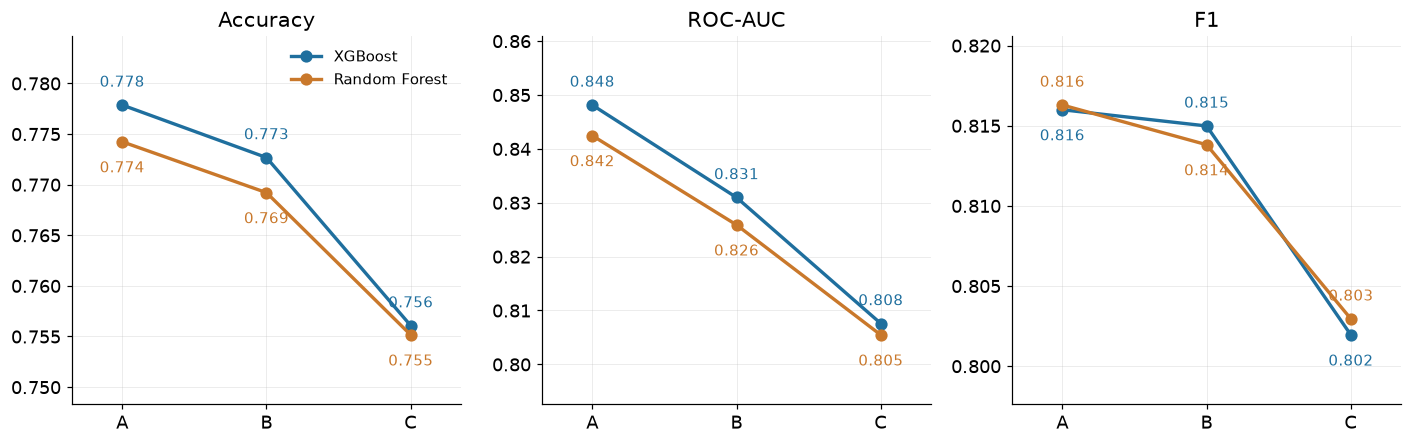

In [26]:
def plot_verlauf(panels, figsize):
    """Kennzahlen entlang A -> B -> C, ein Panel je Kennzahl, eine Linie je Algorithmus."""
    variants = ["A", "B", "C"]
    x = np.arange(len(variants))
    fig, axes = plt.subplots(1, len(panels), figsize=figsize)
    for ax, (key, name) in zip(np.atleast_1d(axes), panels):
        vals = {a: [results[(a, v)][key] for v in variants] for a in ALGOS}
        for algo in ALGOS:
            ax.plot(x, vals[algo], marker="o", markersize=7, linewidth=2.2,
                    color=ALGO_COLOR[algo], label=algo, zorder=3)

        for i in range(len(variants)):
            oben = max(ALGOS, key=lambda a: vals[a][i])
            for algo in ALGOS:
                ax.annotate(f"{vals[algo][i]:.3f}", (x[i], vals[algo][i]),
                            textcoords="offset points",
                            xytext=(0, 12 if algo == oben else -20),
                            ha="center", fontsize=9.5, color=ALGO_COLOR[algo])
        ax.set_xticks(x); ax.set_xticklabels(variants)
        ax.set_xlim(-0.35, len(variants) - 0.65)
        ax.set_title(name, fontweight="normal")
        ax.margins(y=0.30)
    np.atleast_1d(axes)[0].legend(loc="best", fontsize=10)
    plt.tight_layout(); plt.show()

plot_verlauf([("accuracy", "Accuracy"), ("roc_auc", "ROC-AUC"), ("f1", "F1")],
             figsize=(13, 4.2))


### Abbildung 2: Fairness entlang A → B → C



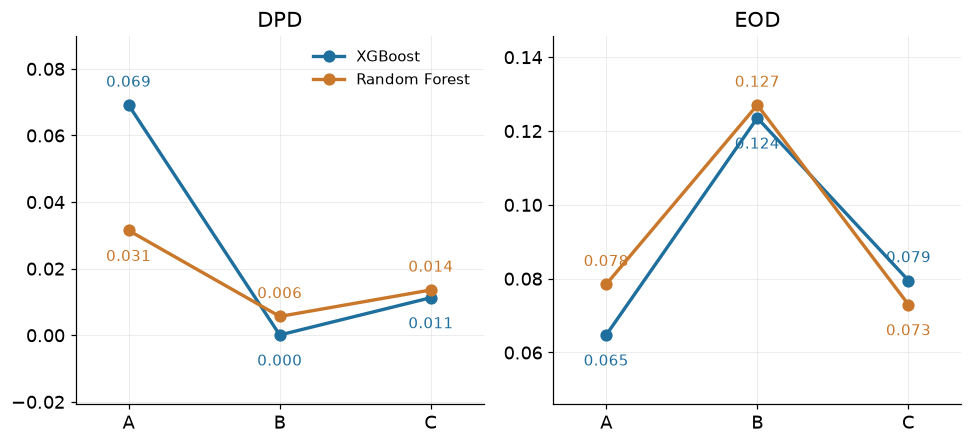

In [27]:
plot_verlauf([("DPD", "DPD"), ("EOD", "EOD")], figsize=(9, 4.2))


### Abbildung 3: Assoziation mit `SEX` und die Proxy-Schwelle

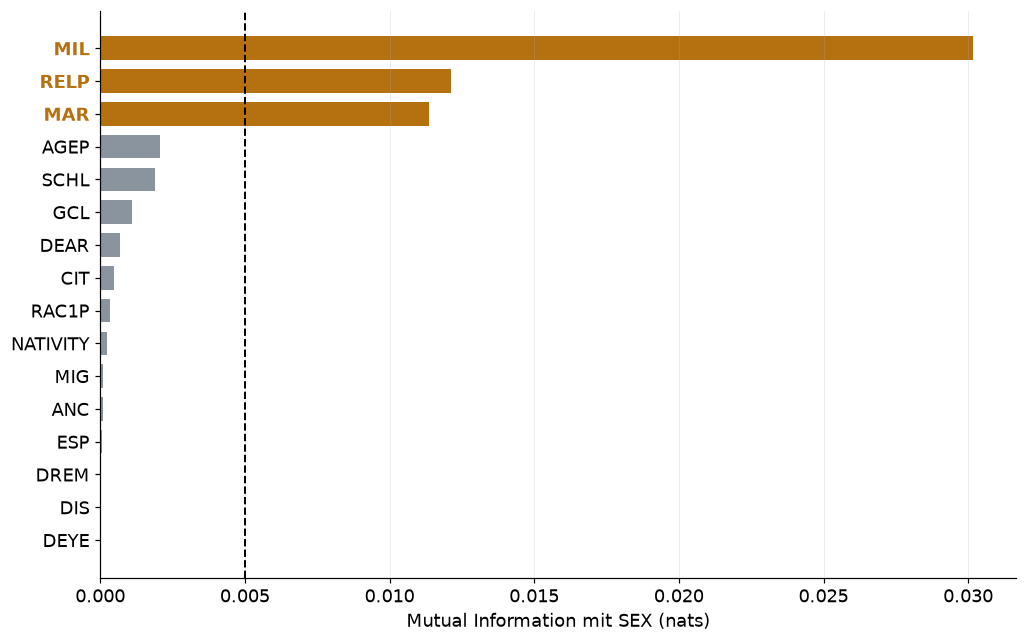

Schwelle MI = 0.005   Luecke: MAR 0.0114 -> AGEP 0.0021   (Faktor 5.5x)


In [28]:
s = sex_assoc.sort_values()
colors = [C_PROXY if f in PROXIES else C_NEUT for f in s.index]

fig, ax = plt.subplots(figsize=(9.5, 6))
ax.barh(s.index.astype(str), s.values, color=colors, height=0.72)
ax.axvline(MI_THRESHOLD, color="black", linestyle="--", linewidth=1.3, zorder=3)
ax.set_xlabel("Mutual Information mit SEX (nats)")
ax.grid(axis="y", visible=False)
for lbl in ax.get_yticklabels():
    if lbl.get_text() in PROXIES:
        lbl.set_color(C_PROXY); lbl.set_fontweight("bold")
plt.tight_layout(); plt.show()

# Die Luecke, die die Schwelle rechtfertigt - als Text unter der Abbildung
_srt   = sex_assoc.sort_values(ascending=False)
_below = _srt[_srt < MI_THRESHOLD]
if len(PROXIES) and len(_below):
    last_proxy, first_out = float(_srt[PROXIES[-1]]), float(_below.iloc[0])
    _faktor_abb = last_proxy / first_out if first_out > 0 else float("inf")
    print(f"Schwelle MI = {MI_THRESHOLD}   Luecke: {PROXIES[-1]} {last_proxy:.4f} -> "
          f"{_below.index[0]} {first_out:.4f}   (Faktor {_faktor_abb:.1f}x)")


### Abbildung 4: Excess

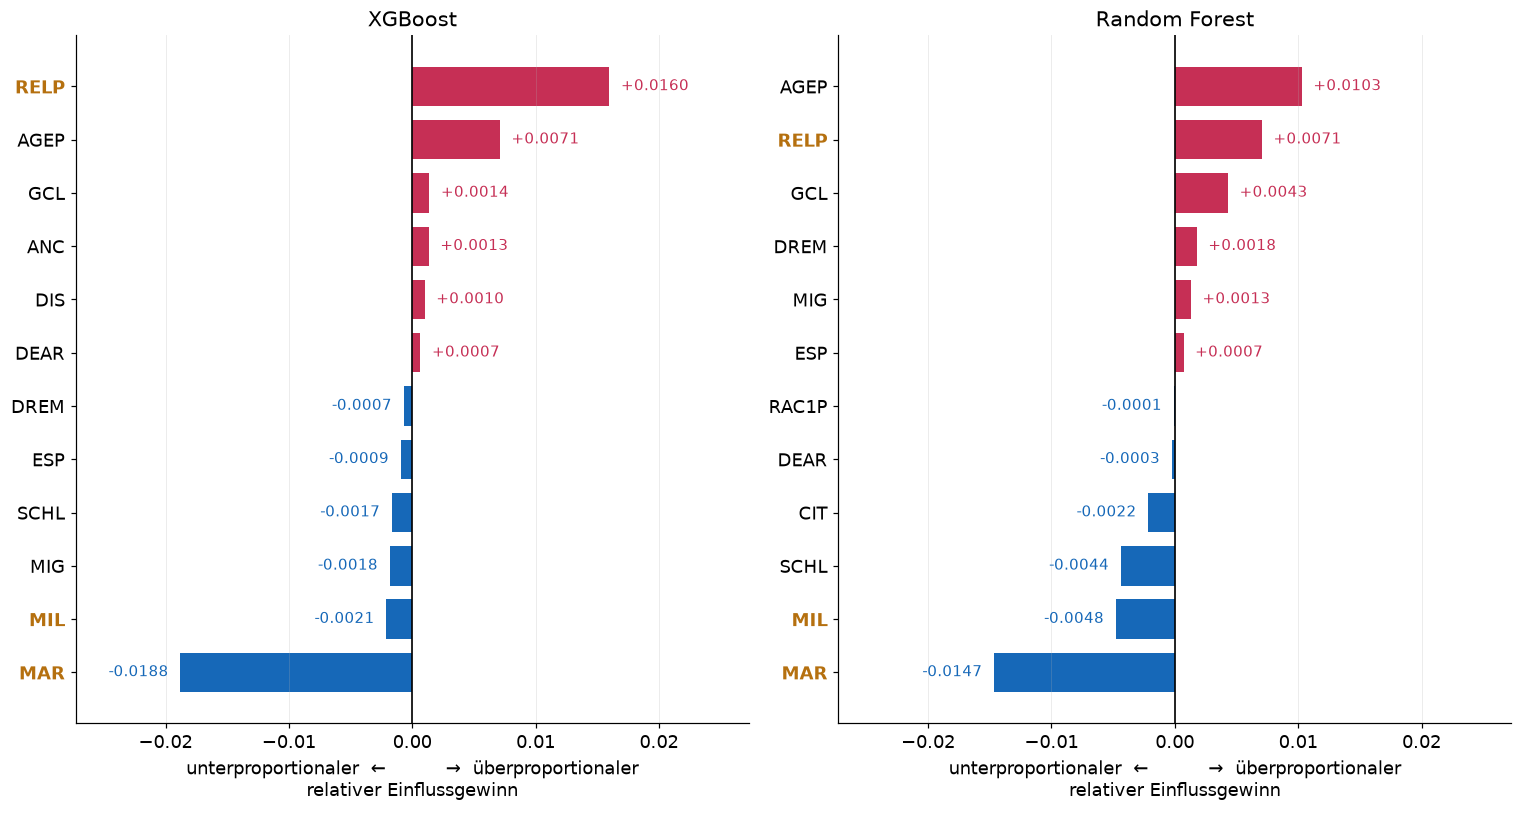

In [29]:
def plot_excess(top=12):
    """Baseline-korrigierter Substitutionseffekt, beide Algorithmen mit gemeinsamer x-Achse."""
    half = top // 2
    sel = {}
    for algo in ALGOS:
        e = substitution_table_corrected(algo)["excess"].sort_values(ascending=False)
        sel[algo] = pd.concat([e.head(half), e.tail(half)]) 
    span = max(float(np.abs(v.values).max()) for v in sel.values())

    fig, axes = plt.subplots(1, 2, figsize=(14, 0.48 * top + 1.8), sharex=True)
    for ax, algo in zip(axes, ALGOS):
        v = sel[algo]
        colors = [C_POS if x > 0 else C_NEG for x in v]
        ax.barh(v.index.astype(str), v.values, color=colors, height=0.74)
        ax.invert_yaxis()
        ax.axvline(0, color="black", linewidth=1.1, zorder=3)
        ax.set_xlim(-span * 1.45, span * 1.45)
        ax.set_title(algo, fontweight="normal")
        ax.set_xlabel("unterproportionaler  ←          →  überproportionaler\nrelativer Einflussgewinn")
        ax.grid(axis="y", visible=False)
        for y, x in enumerate(v.values):
            off = span * 0.05
            ax.text(x + (off if x > 0 else -off), y, f"{x:+.4f}",
                    va="center", ha="left" if x > 0 else "right",
                    fontsize=9.5, color=C_POS if x > 0 else C_NEG)
        _mark_labels(ax)
    plt.tight_layout(); plt.show()

plot_excess()


### Abbildungen 5 bis 7: SHAP-Wichtigkeit je Modell

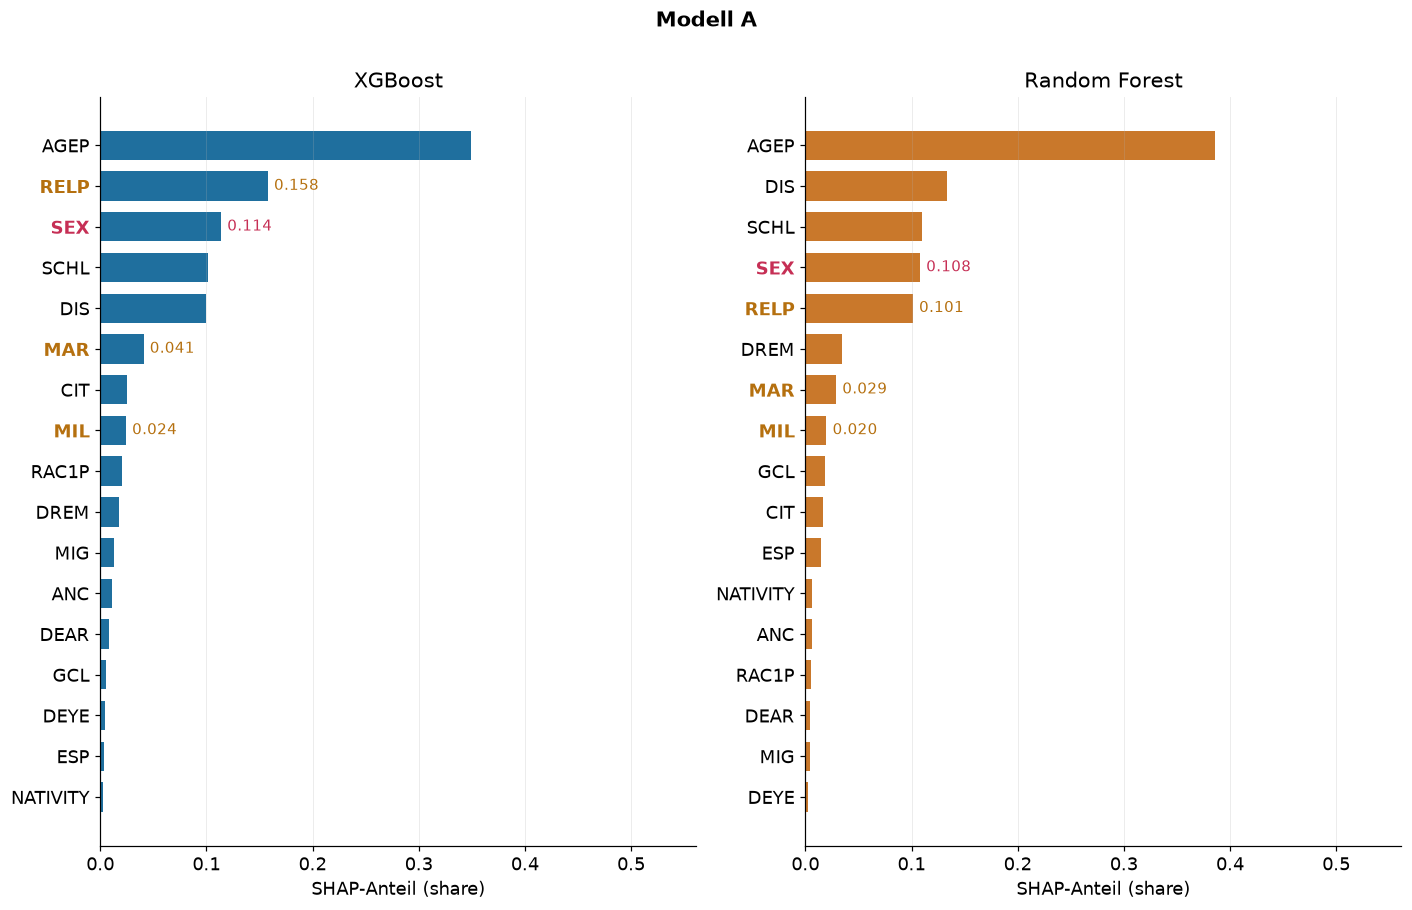

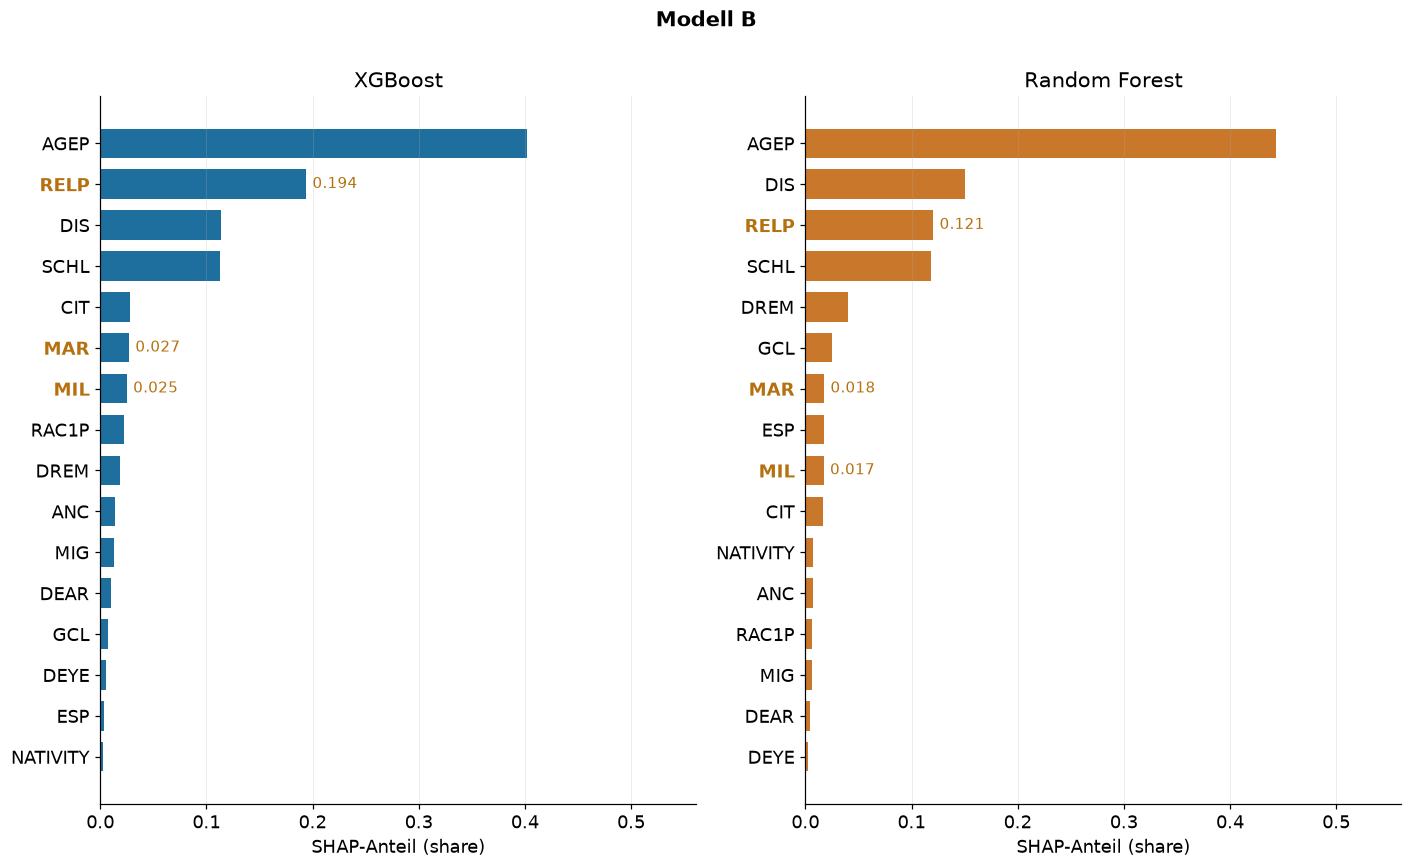

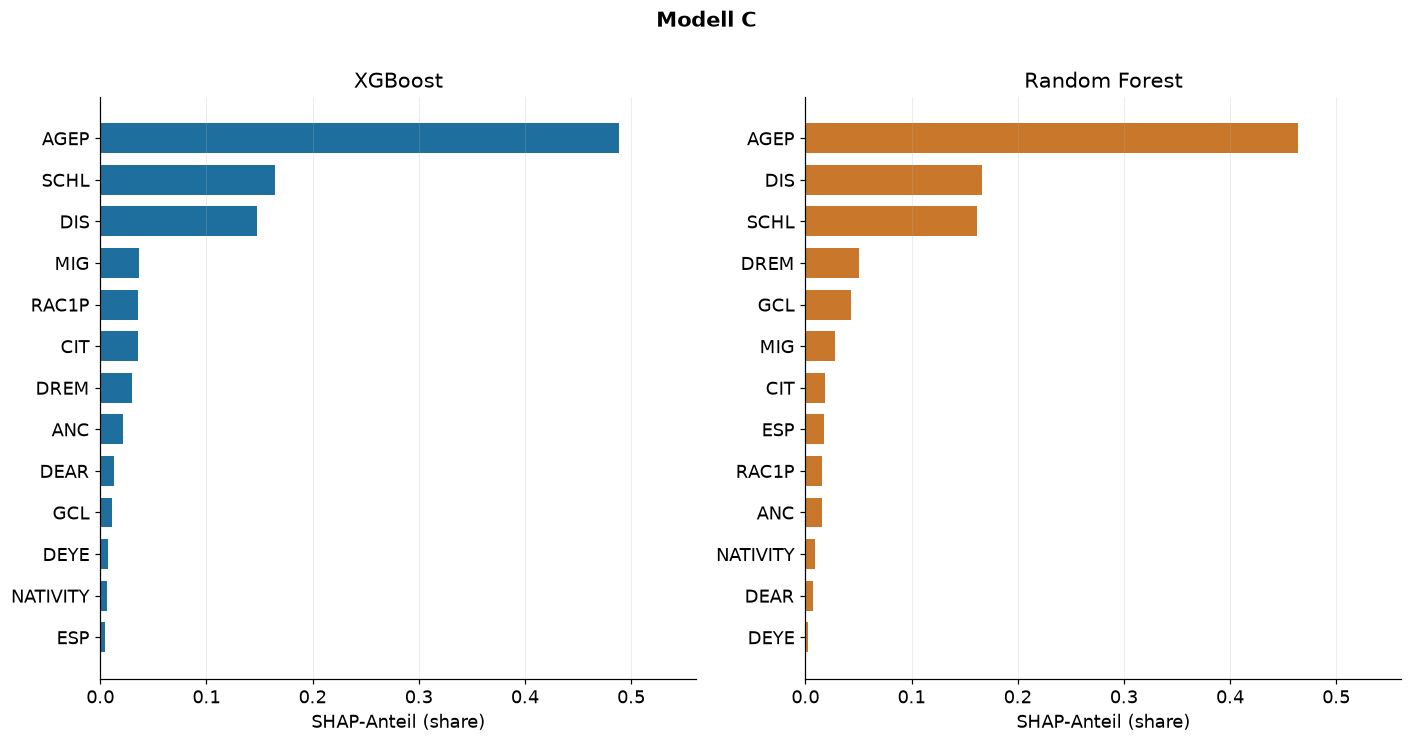

In [30]:
_share_max = max(float((v / v.sum()).max()) for v in shap_imp.values())

def plot_shap_wichtigkeit(variant):
    """Normierter SHAP-Anteil je Merkmal fuer eine Modellvariante, beide Algorithmen nebeneinander."""
    n = len(shap_imp[(ALGOS[0], variant)])
    fig, axes = plt.subplots(1, 2, figsize=(13, 0.38 * n + 1.8))
    for ax, algo in zip(axes, ALGOS):
        imp   = shap_imp[(algo, variant)]
        share = (imp / imp.sum()).sort_values(ascending=False)   
        ax.barh(share.index.astype(str), share.values, color=ALGO_COLOR[algo], height=0.72)
        ax.invert_yaxis()
        ax.set_xlim(0, _share_max * 1.15)
        ax.set_xlabel("SHAP-Anteil (share)")
        ax.set_title(algo, fontweight="normal")
        ax.grid(axis="y", visible=False)

        for y, (f, v) in enumerate(share.items()):
            if f == SENSITIVE or f in PROXIES:
                ax.text(v + _share_max * 0.012, y, f"{v:.3f}", va="center", ha="left",
                        fontsize=9.5, color=C_SEX if f == SENSITIVE else C_PROXY)
        _mark_labels(ax)
    fig.suptitle(f"Modell {variant}", fontsize=14, fontweight="bold", y=1.0)
    plt.tight_layout(); plt.show()

for _v in ["A", "B", "C"]:
    plot_shap_wichtigkeit(_v)


---

# Teil 2: Robustheitsprüfung

Teil I beruht auf einem Haushaltssplit (`random_state = 42`) und einer SHAP-Stichprobe. Teil 2 wiederholt deshalb die gesamte Auswertung mit fünf Zufallsstartwerten und prüft zusätzlich zwei Einwände.

## 14. Rechenkern der Robustheitsprüfung

### 14.1 Placebokontrolle

In [31]:
# Placebo-Auswahl: gleiches Gewicht wie SEX, aber möglichst ohne Geschlechtsbezug
MI_STRENG = MI_THRESHOLD / 5    
N_PLACEBO = 1                   

_share_A = {algo: shap_imp[(algo, "A")] / shap_imp[(algo, "A")].sum() for algo in ALGOS}

_rows = []
for f in FEATURES:
    if f == SENSITIVE:
        continue
    row, log_abstand = {"Merkmal": f, "SEX_MI": float(sex_assoc[f])}, []
    for algo in ALGOS:
        r = float(_share_A[algo][f]) / float(_share_A[algo][SENSITIVE])
        row[f"Anteil_{algo.split()[0]}"]      = float(_share_A[algo][f])
        row[f"Verhaeltnis_{algo.split()[0]}"] = r
        log_abstand.append(abs(np.log(max(r, 1e-9))))     
    row["Gewichtsabstand"] = float(np.mean(log_abstand))  
    _rows.append(row)

placebo_tab = pd.DataFrame(_rows)

placebo_tab["geeignet"] = placebo_tab["SEX_MI"] < MI_STRENG

placebo_tab = (placebo_tab.sort_values(["geeignet", "Gewichtsabstand"],
                                       ascending=[False, True]).reset_index(drop=True))
PLACEBOS = list(placebo_tab.loc[placebo_tab["geeignet"], "Merkmal"].head(N_PLACEBO))
assert PLACEBOS, (f"Kein geeignetes Placebo gefunden - in dieser Datenquelle liegt jedes "
                  f"Merkmal ueber MI_STRENG = {MI_STRENG}. Abschnitt 17 ist dann nicht rechenbar.")

print(f"SEX-Anteil in Modell A:  " +
      "   ".join(f"{a} {_share_A[a][SENSITIVE]:.4f}" for a in ALGOS))
print(f"Bedingung 1: SEX-MI < {MI_STRENG}   |   Bedingung 2: Gewichtsabstand moeglichst klein\n")
print(placebo_tab.round(4).to_string(index=False))

print(f"\n>> Gewaehlt als Placebo: {', '.join(PLACEBOS)}")
_pt = placebo_tab.set_index("Merkmal")
for p in PLACEBOS:
    print(f"   {p:5s}: SEX-MI {_pt.loc[p, 'SEX_MI']:.4f} (Proxy-Schwelle {MI_THRESHOLD})   |   "
          f"Gewicht " + " / ".join(f"{_pt.loc[p, 'Verhaeltnis_' + a.split()[0]]:.2f}x ({a})"
                                   for a in ALGOS) + " von SEX")
print("\nJe naeher das Verhaeltnis an 1.00 liegt, desto belastbarer ist der Placebo-Vergleich.")

SEX-Anteil in Modell A:  XGBoost 0.1138   Random Forest 0.1080
Bedingung 1: SEX-MI < 0.001   |   Bedingung 2: Gewichtsabstand moeglichst klein

 Merkmal  SEX_MI  Anteil_XGBoost  Verhaeltnis_XGBoost  Anteil_Random  Verhaeltnis_Random  Gewichtsabstand  geeignet
     DIS  0.0000          0.1000               0.8786         0.1338              1.2387           0.1718      True
    DREM  0.0000          0.0172               0.1511         0.0344              0.3187           1.5165      True
     CIT  0.0005          0.0255               0.2245         0.0164              0.1522           1.6884      True
   RAC1P  0.0003          0.0200               0.1758         0.0057              0.0524           2.3438      True
     ANC  0.0001          0.0112               0.0981         0.0058              0.0538           2.6224      True
     ESP  0.0000          0.0038               0.0337         0.0151              0.1401           2.6774      True
     MIG  0.0001          0.0134            

### 14.2 Wiederholung für fünf Seeds

In [32]:
# Komplette Auswertung für mehrere Zufallsstartwerte
SEEDS      = [RANDOM_STATE, 7, 13, 101, 2024]
N_SHAP_ROB = 1500      

VARIANTEN = {"A": FEATURES, "B": FEATURES_B, "C": FEATURES_C}
for _p in PLACEBOS:                                   
    VARIANTEN[f"P_{_p}"] = [c for c in FEATURES if c != _p]

rob_metrics  = []
rob_imp      = {}
rob_mi       = {}

print(f"Rechenkern: {len(SEEDS)} Seeds x {len(VARIANTEN)} Merkmalsraeume x {len(ALGOS)} Algorithmen "
      f"= {len(SEEDS) * len(VARIANTEN) * len(ALGOS)} Modelle\n")
_t_start = time.time()

for _i, seed in enumerate(SEEDS, start=1):
    _g         = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed)
    _itr, _ite = next(_g.split(X_all, y_all, groups=HH))
    Xtr, Xte   = X_all.iloc[_itr], X_all.iloc[_ite]
    ytr, yte   = y_all.iloc[_itr], y_all.iloc[_ite]
    sx_s = Xte[SENSITIVE]
    Xs   = Xte.loc[Xte.sample(n=min(N_SHAP_ROB, len(Xte)), random_state=seed).index]


    _s = Xtr.sample(n=min(100_000, len(Xtr)), random_state=seed)
    _c = [c for c in FEATURES if c != SENSITIVE]
    rob_mi[seed] = pd.Series(
        mutual_info_classif(_s[_c], _s[SENSITIVE],
                            discrete_features=[c not in CONTINUOUS for c in _c],
                            random_state=seed),
        index=_c).sort_values(ascending=False)


    for variante, cols in VARIANTEN.items():
        for algo in ALGOS:
            m = make_model(algo, random_state=seed).fit(Xtr[cols], ytr)
            pr = m.predict_proba(Xte[cols])[:, 1]
            yp = (pr >= SCHWELLE).astype(int)  

            rob_metrics.append({
                "seed": seed, "Algorithmus": algo, "Variante": variante,
                "Accuracy": accuracy_score(yte, yp),
                "ROC_AUC":  roc_auc_score(yte, pr),
                "F1":       f1_score(yte, yp),
                "DPD":      demographic_parity_difference(yte, yp, sensitive_features=sx_s),
                "EOD":      equalized_odds_difference(yte, yp, sensitive_features=sx_s),
            })
            rob_imp[(seed, algo, variante)] = shap_mean_abs(m, Xs[cols])
            del m
    gc.collect()

    _el = time.time() - _t_start
    print(f"  Seed {seed:>5}  fertig  ({_el/60:5.1f} min verbraucht, "
          f"noch ca. {_el/_i*(len(SEEDS)-_i)/60:4.1f} min)")

rob_metrics = pd.DataFrame(rob_metrics)
print(f"\nFertig in {(time.time()-_t_start)/60:.1f} min. "
      f"{len(rob_metrics)} Modellauswertungen gespeichert.")


def excess_vector(a, b, entfernt):
    """Baseline-korrigierter Substitutionseffekt aus zwei SHAP-Wichtigkeitsvektoren.

    Identisch zur Formel aus Abschnitt 8.2, aber ohne Rueckgriff auf globale Zustaende:
    excess = share_B - share_A * k   mit   k = 1 / (1 - share_A[entfernt]).
    """
    sA = a / a.sum()
    sB = b / b.sum()
    k  = 1.0 / (1.0 - float(sA[entfernt]))
    return sB - sA.reindex(sB.index) * k

Rechenkern: 5 Seeds x 4 Merkmalsraeume x 2 Algorithmen = 40 Modelle

  Seed    42  fertig  (  2.9 min verbraucht, noch ca. 11.8 min)
  Seed     7  fertig  (  5.9 min verbraucht, noch ca.  8.9 min)
  Seed    13  fertig  (  9.0 min verbraucht, noch ca.  6.0 min)
  Seed   101  fertig  ( 12.0 min verbraucht, noch ca.  3.0 min)
  Seed  2024  fertig  ( 15.0 min verbraucht, noch ca.  0.0 min)

Fertig in 15.0 min. 40 Modellauswertungen gespeichert.


## 15. Ergebnis 1: Güte und Fairness über fünf Splits 

In [33]:
_kern = rob_metrics[rob_metrics["Variante"].isin(["A", "B", "C"])]
rob_summary = (_kern.groupby(["Algorithmus", "Variante"])[["Accuracy", "ROC_AUC", "DPD", "EOD"]]
               .agg(["mean", "std"]).round(4))
print(f"Mittelwert und Standardabweichung ueber {len(SEEDS)} Splits:\n")
print(rob_summary.to_string())


_w = _kern.pivot_table(index=["Algorithmus", "seed"], columns="Variante",
                       values=["ROC_AUC", "DPD", "EOD"])
paar_rows = []
for algo in ALGOS:
    g = _w.loc[algo]
    for met in ["ROC_AUC", "DPD", "EOD"]:
        for von, nach in [("A", "B"), ("A", "C")]:
            d = g[(met, nach)] - g[(met, von)]
            mu, sd = float(d.mean()), float(d.std())
            paar_rows.append({
                "Algorithmus": algo, "Kennzahl": met, "Uebergang": f"{von}->{nach}",
                "Differenz": mu, "SD": sd,
                "mean/SD": mu / sd if sd > 0 else np.nan,
                "Richtung gleich": f"{int((np.sign(d) == np.sign(mu)).sum())}/{len(d)}",
                "Vorzeichen stabil": bool((np.sign(d) == np.sign(mu)).all()),
            })
paar_df = pd.DataFrame(paar_rows)

_urteil_kennzahl = {}
for met in ["ROC_AUC", "DPD", "EOD"]:
    for ueb in ["A->B", "A->C"]:
        g = paar_df[(paar_df.Kennzahl == met) & (paar_df.Uebergang == ueb)]
        gleiche_richtung = np.sign(g["Differenz"]).nunique() == 1
        _urteil_kennzahl[(met, ueb)] = (
            "belastbar" if gleiche_richtung and g["Vorzeichen stabil"].all()
            else "algorithmusabhaengig" if not gleiche_richtung else "nicht belastbar")
paar_df["Urteil"] = [_urteil_kennzahl[(r.Kennzahl, r.Uebergang)]
                     for _, r in paar_df.iterrows()]

print("\n\nGepaarte Differenzen (je Seed derselbe Split fuer beide Modelle):\n")
print(paar_df.round(4).to_string(index=False))
print("\n  Urteil: gleiches Vorzeichen in allen Splits UND dieselbe Richtung in\n"
      "  beiden Algorithmen. SD und mean/SD dienen der Einordnung, nicht der Entscheidung.")


print(f"\n\nProxy-Auswahl je Seed (MI >= {MI_THRESHOLD}):")
_mi_all = pd.DataFrame(rob_mi)
proxy_je_seed = {s: sorted(rob_mi[s][rob_mi[s] >= MI_THRESHOLD].index) for s in SEEDS}
for s in SEEDS:
    print(f"  Seed {s:>5}: {proxy_je_seed[s]}")
_identisch = all(v == sorted(PROXIES) for v in proxy_je_seed.values())
print(f"\n  In allen {len(SEEDS)} Splits identisch mit der Auswahl aus Abschnitt 9: "
      f"{'JA' if _identisch else 'NEIN'}")
print("\nMI-Werte der Proxy-Kandidaten ueber die Seeds (Mittelwert +/- SD):")
print(pd.DataFrame({"MI_mean": _mi_all.mean(axis=1), "MI_SD": _mi_all.std(axis=1)})
      .loc[[f for f in PROXIES + ["SCHL", "AGEP"] if f in _mi_all.index]]
      .round(4).to_string())

Mittelwert und Standardabweichung ueber 5 Splits:

                       Accuracy         ROC_AUC             DPD             EOD        
                           mean     std    mean     std    mean     std    mean     std
Algorithmus   Variante                                                                 
Random Forest A          0.7757  0.0014  0.8441  0.0015  0.0275  0.0026  0.0870  0.0058
              B          0.7709  0.0013  0.8272  0.0015  0.0060  0.0018  0.1318  0.0052
              C          0.7559  0.0007  0.8056  0.0007  0.0143  0.0018  0.0742  0.0041
XGBoost       A          0.7798  0.0016  0.8491  0.0015  0.0701  0.0021  0.0657  0.0040
              B          0.7744  0.0011  0.8318  0.0016  0.0012  0.0012  0.1240  0.0032
              C          0.7573  0.0013  0.8073  0.0008  0.0125  0.0025  0.0794  0.0053


Gepaarte Differenzen (je Seed derselbe Split fuer beide Modelle):

  Algorithmus Kennzahl Uebergang  Differenz     SD  mean/SD Richtung gleich  Vorzeichen 

### Abbildung Güte und Fairness über fünf Splits

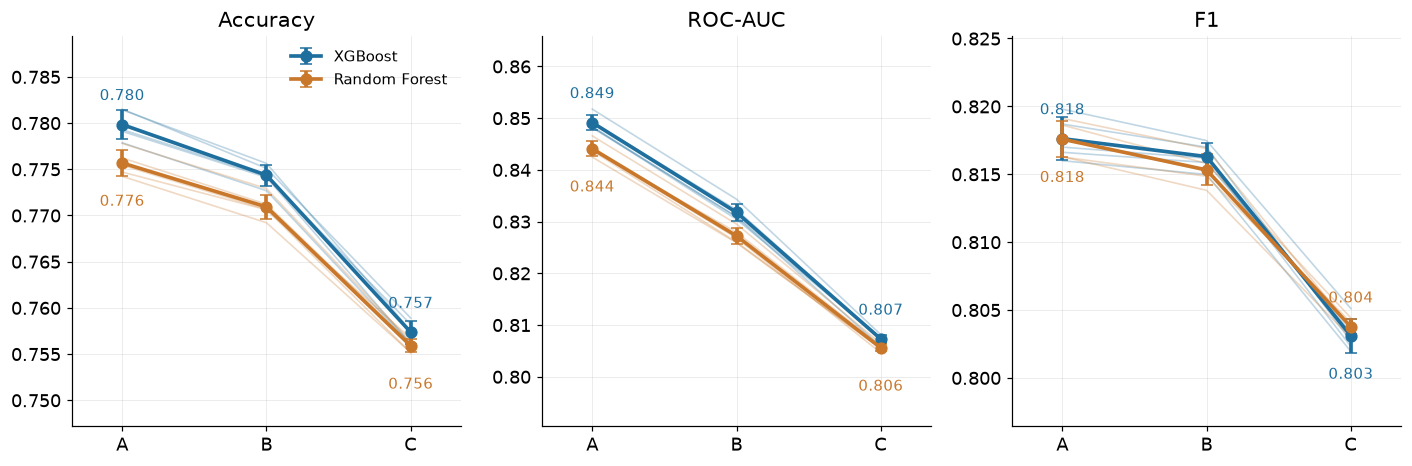

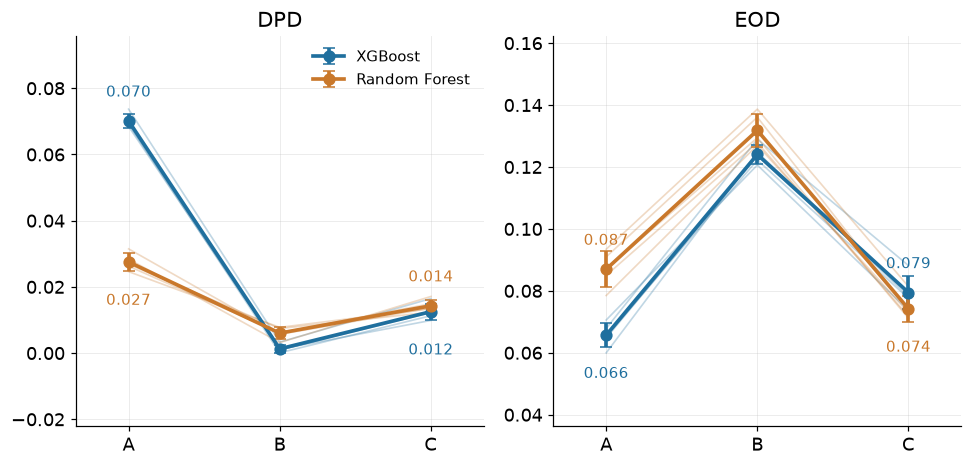

In [34]:
def plot_verlauf_rob(panels, figsize):
    """Kennzahlen entlang A -> B -> C ueber alle Seeds: duenn = Split, kraeftig = Mittelwert +- SD."""
    variants = ["A", "B", "C"]
    x = np.arange(len(variants))
    fig, axes = plt.subplots(1, len(panels), figsize=figsize)
    for ax, (key, name) in zip(np.atleast_1d(axes), panels):
        mittel = {}
        for algo in ALGOS:
            g = rob_metrics[(rob_metrics.Algorithmus == algo)
                            & (rob_metrics.Variante.isin(variants))]
            w = g.pivot_table(index="seed", columns="Variante", values=key)[variants]
            mittel[algo] = w.mean().values
            for _, zeile in w.iterrows():
                ax.plot(x, zeile.values, color=ALGO_COLOR[algo], alpha=0.28,
                        linewidth=1.1, zorder=2)
            ax.errorbar(x, w.mean().values, yerr=w.std().values, marker="o", markersize=7,
                        linewidth=2.4, capsize=4, color=ALGO_COLOR[algo], label=algo, zorder=3)

        for i in (0, len(variants) - 1):
            oben = max(ALGOS, key=lambda a: mittel[a][i])
            for algo in ALGOS:
                ax.annotate(f"{mittel[algo][i]:.3f}", (x[i], mittel[algo][i]),
                            textcoords="offset points",
                            xytext=(0, 16 if algo == oben else -28),
                            ha="center", fontsize=9.5, color=ALGO_COLOR[algo])
        ax.set_xticks(x); ax.set_xticklabels(variants)
        ax.set_xlim(-0.35, len(variants) - 0.65)
        ax.set_title(name, fontweight="normal")
        ax.margins(y=0.30)
    np.atleast_1d(axes)[0].legend(loc="best", fontsize=10)
    plt.tight_layout(); plt.show()

# R1a: Guete
plot_verlauf_rob([("Accuracy", "Accuracy"), ("ROC_AUC", "ROC-AUC"), ("F1", "F1")], figsize=(13, 4.4))
# R1b: Fairness
plot_verlauf_rob([("DPD", "DPD"), ("EOD", "EOD")], figsize=(9, 4.4))


## 16. Ergebnis 2: Substitutionseffekt

In [35]:
# Substitutionseffekt je Seed neu berechnen
_ex = {}
for algo in ALGOS:
    for s in SEEDS:
        _ex[(algo, s)] = excess_vector(rob_imp[(s, algo, "A")],
                                       rob_imp[(s, algo, "B")], SENSITIVE)


_top = []
for algo in ALGOS:
    _m = pd.DataFrame({s: _ex[(algo, s)] for s in SEEDS}).mean(axis=1).drop(PLACEBOS)
    _top += list(_m.sort_values(ascending=False).head(2).index)
FOKUS = [f for f in dict.fromkeys(PROXIES + ["AGEP", "SCHL"] + _top)
         if f not in PLACEBOS and f in FEATURES_B]

stab_rows = []
for algo in ALGOS:
    E = pd.DataFrame({s: _ex[(algo, s)] for s in SEEDS})
    for f in E.index:
        mu, sd = float(E.loc[f].mean()), float(E.loc[f].std())
        stab_rows.append({
            "Algorithmus": algo, "Merkmal": f,
            "excess_mean": mu, "SD": sd,
            "min": float(E.loc[f].min()), "max": float(E.loc[f].max()),
            "mean/SD": mu / sd if sd > 0 else np.nan,
            "Vorzeichen stabil": bool((np.sign(E.loc[f]) == np.sign(mu)).all()),
        })
excess_stab = pd.DataFrame(stab_rows)

_urteil_excess = {}
for f in excess_stab["Merkmal"].unique():
    g = excess_stab[excess_stab.Merkmal == f]
    gleiche_richtung = np.sign(g["excess_mean"]).nunique() == 1
    _urteil_excess[f] = ("belastbar" if gleiche_richtung and g["Vorzeichen stabil"].all()
                         else "algorithmusabhaengig" if not gleiche_richtung
                         else "nicht belastbar")
excess_stab["Urteil"] = excess_stab["Merkmal"].map(_urteil_excess)

print(f"Substitutionseffekt ueber {len(SEEDS)} Splits – Fokusmerkmale {FOKUS}:\n")
print(excess_stab[excess_stab["Merkmal"].isin(FOKUS)]
      .sort_values(["Algorithmus", "excess_mean"], ascending=[True, False])
      .round(4).to_string(index=False))

print("\n\nEinordnung der Werte aus Teil I:")
print(f"  Teil I (Seed {RANDOM_STATE}, {N_SHAP} SHAP-Zeilen)  |  derselbe Split im Rechenkern "
      f"({N_SHAP_ROB} Zeilen)  |  Mittel +/- SD ueber alle Splits\n")
for algo in ALGOS:
    t42 = substitution_table_corrected(algo)["excess"]
    for f in FOKUS:
        z   = excess_stab[(excess_stab.Algorithmus == algo) & (excess_stab.Merkmal == f)].iloc[0]
        e42 = float(_ex[(algo, RANDOM_STATE)][f])
        gedeckt = bool(z["SD"] > 0 and abs(float(t42[f]) - z["excess_mean"]) <= 2 * z["SD"])
        print(f"  {algo:13s} {f:5s}: {float(t42[f]):+.4f}  |  {e42:+.4f}  |  "
              f"{z['excess_mean']:+.4f} +/- {z['SD']:.4f}   "
              f"{'im Streubereich' if gedeckt else 'ausserhalb von 2 SD'}")

print("\n\nStaerkster Gewinner je Split:")
for algo in ALGOS:
    E = pd.DataFrame({s: _ex[(algo, s)] for s in SEEDS})
    sieger = E.idxmax()
    print(f"  {algo:13s}: " + "  ".join(f"Seed {s}: {sieger[s]}" for s in SEEDS))

Substitutionseffekt ueber 5 Splits – Fokusmerkmale ['MIL', 'RELP', 'MAR', 'AGEP', 'SCHL']:

  Algorithmus Merkmal  excess_mean     SD     min     max  mean/SD  Vorzeichen stabil               Urteil
Random Forest    AGEP       0.0082 0.0058  0.0016  0.0138   1.4208               True      nicht belastbar
Random Forest    RELP       0.0067 0.0021  0.0039  0.0091   3.1912               True            belastbar
Random Forest    SCHL       0.0012 0.0051 -0.0047  0.0063   0.2421              False algorithmusabhaengig
Random Forest     MIL      -0.0037 0.0008 -0.0046 -0.0026  -4.8198               True            belastbar
Random Forest     MAR      -0.0140 0.0011 -0.0155 -0.0124 -12.5305               True            belastbar
      XGBoost    RELP       0.0146 0.0035  0.0111  0.0195   4.2377               True            belastbar
      XGBoost    AGEP       0.0033 0.0054 -0.0018  0.0107   0.6096              False      nicht belastbar
      XGBoost    SCHL      -0.0005 0.0012 -0.0023  0

### Abbildung: Substitutionseffekt über die Splits

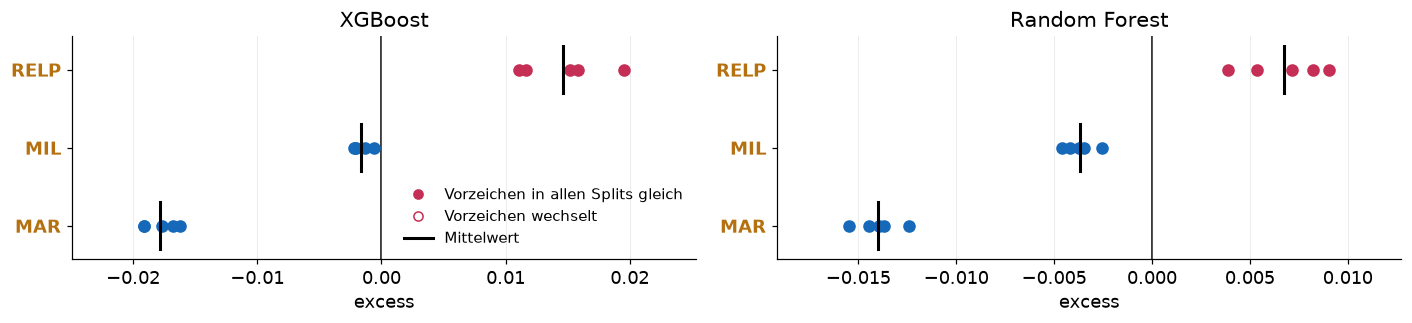

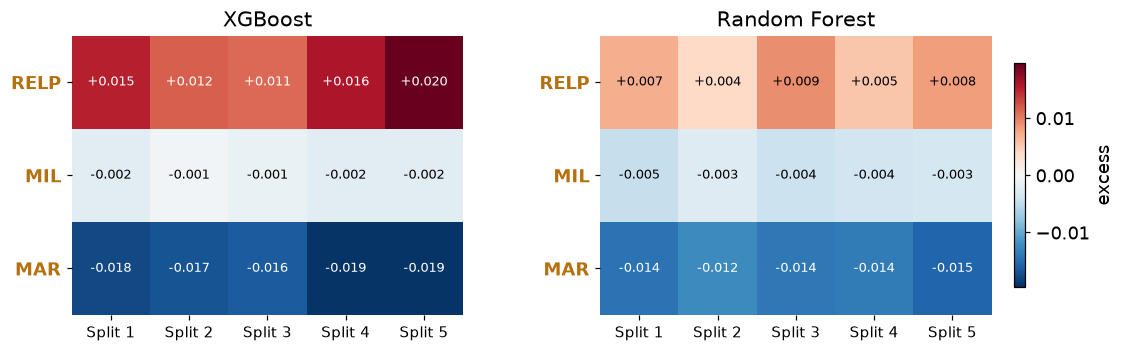

In [36]:
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

ABB_MERKMALE = list(PROXIES)

def _excess_matrix(algo):
    """Proxy-Kandidaten x Seeds, Zeilen absteigend nach Mittelwert."""
    E = pd.DataFrame({s: _ex[(algo, s)] for s in SEEDS}).loc[ABB_MERKMALE]
    return E.loc[E.mean(axis=1).sort_values(ascending=False).index]

def _stabil(zeile):
    return bool((zeile > 0).all() or (zeile < 0).all())


fig, axes = plt.subplots(1, 2, figsize=(13, 0.5 * len(ABB_MERKMALE) + 1.6))
for ax, algo in zip(axes, ALGOS):
    E = _excess_matrix(algo)
    for y, f in enumerate(E.index):
        werte = E.loc[f].values
        mu    = werte.mean()
        col   = C_POS if mu > 0 else C_NEG
        ax.scatter(werte, [y] * len(werte), s=48,
                   facecolor=col if _stabil(E.loc[f]) else "white",
                   edgecolor=col, linewidth=1.3, zorder=3)
        ax.plot([mu, mu], [y - 0.3, y + 0.3], color="black", linewidth=2, zorder=4)
    ax.axvline(0, color="black", linewidth=1, zorder=1)
    ax.set_yticks(range(len(E.index))); ax.set_yticklabels(E.index)
    ax.invert_yaxis()
    ax.set_xlabel("excess")
    ax.set_title(algo, fontweight="normal")
    ax.grid(axis="y", visible=False)
    ax.margins(x=0.15)
    _mark_labels(ax)
axes[0].legend(handles=[
    Line2D([], [], marker="o", linestyle="", color=C_POS, label="Vorzeichen in allen Splits gleich"),
    Line2D([], [], marker="o", linestyle="", markerfacecolor="white", color=C_POS, label="Vorzeichen wechselt"),
    Line2D([], [], color="black", linewidth=2, label="Mittelwert")],
    loc="lower right", fontsize=9.5)
plt.tight_layout(); plt.show()

# Heatmap
_vmax = max(float(_excess_matrix(a).abs().values.max()) for a in ALGOS)
fig, axes = plt.subplots(1, 2, figsize=(13, 0.5 * len(ABB_MERKMALE) + 1.8), gridspec_kw={"wspace": 0.35})
for ax, algo in zip(axes, ALGOS):
    E  = _excess_matrix(algo)
    im = ax.imshow(E.values, cmap="RdBu_r", norm=TwoSlopeNorm(0, -_vmax, _vmax), aspect="auto")
    ax.set_xticks(range(len(SEEDS)))
    ax.set_xticklabels([f"Split {i + 1}" for i in range(len(SEEDS))], fontsize=10)
    ax.set_yticks(range(len(E.index))); ax.set_yticklabels(E.index)
    ax.grid(False)
    for sp in ax.spines.values():
        sp.set_visible(False)
    for i, f in enumerate(E.index):
        for j, s in enumerate(SEEDS):
            v = float(E.loc[f, s])
            ax.text(j, i, f"{v:+.3f}", ha="center", va="center", fontsize=8.5,
                    color="white" if abs(v) > _vmax * 0.55 else "black")
        if not _stabil(E.loc[f]):
            ax.text(len(SEEDS) - 0.4, i, "✕", ha="left", va="center", fontsize=11, color=C_NEUT)
    ax.set_title(algo, fontweight="normal")
    _mark_labels(ax)
fig.colorbar(im, ax=axes, shrink=0.8, label="excess", pad=0.02)
plt.show()


## 17. Ergebnis 3: Placebo-Kontrolle

In [37]:
# Placebo-Kontrolle: reagiert ein Merkmal spezifisch auf das Entfernen von SEX?
_p_pla = PLACEBOS[0]

spez_rows = []
for algo in ALGOS:
    for f in FOKUS:
        e_sex = [float(_ex[(algo, s)][f]) for s in SEEDS]
        e_pla = [float(excess_vector(rob_imp[(s, algo, "A")],
                                     rob_imp[(s, algo, f"P_{_p_pla}")], _p_pla)[f])
                 for s in SEEDS]
        d  = [a - b for a, b in zip(e_sex, e_pla)]
        mu = float(np.mean(d))
        spez_rows.append({
            "Algorithmus": algo, "Merkmal": f,
            "ohne_SEX":     float(np.mean(e_sex)),
            "ohne_Placebo": float(np.mean(e_pla)),
            "Differenz":    mu,
            "SD":           float(np.std(d, ddof=1)),
            "Vorzeichen stabil": bool((np.sign(d) == np.sign(mu)).all()),
        })
placebo_spez = pd.DataFrame(spez_rows)

_urteil_placebo = {}
for f in FOKUS:
    g = placebo_spez[placebo_spez.Merkmal == f]
    if np.sign(g["Differenz"]).nunique() == 1 and g["Vorzeichen stabil"].all():
        _urteil_placebo[f] = ("SEX-spezifisch (Gewinn)" if g["Differenz"].mean() > 0
                              else "SEX-spezifisch (Verlust)")
    else:
        _urteil_placebo[f] = "kein Spezifitaetsbeleg"
placebo_spez["Urteil"] = placebo_spez["Merkmal"].map(_urteil_placebo)

print(f"Placebo-Kontrolle: entfernt wird {_p_pla} anstelle von {SENSITIVE}")
print(f"Mittelwerte ueber {len(SEEDS)} Zufallsaufteilungen, gepaart je Aufteilung\n")
print(placebo_spez.round(4).to_string(index=False))


Placebo-Kontrolle: entfernt wird DIS anstelle von SEX
Mittelwerte ueber 5 Zufallsaufteilungen, gepaart je Aufteilung

  Algorithmus Merkmal  ohne_SEX  ohne_Placebo  Differenz     SD  Vorzeichen stabil                   Urteil
      XGBoost     MIL   -0.0017       -0.0008    -0.0009 0.0007               True SEX-spezifisch (Verlust)
      XGBoost    RELP    0.0146       -0.0085     0.0231 0.0020               True  SEX-spezifisch (Gewinn)
      XGBoost     MAR   -0.0178       -0.0024    -0.0154 0.0009               True SEX-spezifisch (Verlust)
      XGBoost    AGEP    0.0033       -0.0135     0.0168 0.0040               True  SEX-spezifisch (Gewinn)
      XGBoost    SCHL   -0.0005       -0.0015     0.0011 0.0028              False   kein Spezifitaetsbeleg
Random Forest     MIL   -0.0037       -0.0009    -0.0028 0.0008               True SEX-spezifisch (Verlust)
Random Forest    RELP    0.0067       -0.0051     0.0118 0.0009               True  SEX-spezifisch (Gewinn)
Random Forest     

## 18. Sensitivitätsprüfung: One-Hot-Kodierung der nominalen Merkmale

**Was kodiert wird:**

| Merkmal(e) | Behandlung | Grund |
|---|---|---|
| `RELP`, `MAR`, `RAC1P`, `CIT`, `ANC`, `ESP`, `MIG`, `MIL` | One-Hot | nominal, Codes ohne Rangfolge |
| `AGEP` | unverändert | stetig |
| `SCHL` | unverändert | ordinal |
| `DIS`, `DEAR`, `DEYE`, `DREM`, `NATIVITY`, `GCL`, `SEX` | unverändert | binär |

### 18.1 Prüfung: echte fehlende Werte oder ein Zahlencode?

In [38]:
NOMINAL = ["RELP", "MAR", "RAC1P", "CIT", "ANC", "ESP", "MIG", "MIL"]

_fehlt_nominal_oh = [c for c in NOMINAL if c not in FEATURES]
assert not _fehlt_nominal_oh, (
    f"Diese Merkmale fehlen in der aktuellen Datenquelle: {_fehlt_nominal_oh}. "
    f"NOMINAL an ACS{TASK} / Jahrgang {YEAR} anpassen (ab 2019 heisst RELP z.B. RELSHIPP).")

HAT_NAN_OH = bool(X_train[NOMINAL].isna().any().any())

print(X_train[NOMINAL].isna().sum())
print(X_train["ESP"].value_counts(dropna=False).head())
print(f"\nEchte NaN in den nominalen Merkmalen: {HAT_NAN_OH}")

if HAT_NAN_OH:
    _rest_oh = [c for c in FEATURES if c not in NOMINAL]
    print("\nNaN in nicht kodierten Merkmalen:")
    print(X_train[_rest_oh].isna().sum().loc[lambda s: s > 0])

print("\nAuspraegungen je nominalem Merkmal (Trainingsmenge):")
for _f_oh in NOMINAL:
    _codes_oh = np.sort(X_train[_f_oh].dropna().unique())
    print(f"  {_f_oh:6s} {len(_codes_oh):3d}   Codes: "
          f"{np.array2string(_codes_oh, precision=0, max_line_width=80)}")

RELP     0
MAR      0
RAC1P    0
CIT      0
ANC      0
ESP      0
MIG      0
MIL      0
dtype: int64
ESP
0.0    238332
1.0      1431
2.0       693
7.0       657
5.0       248
Name: count, dtype: int64

Echte NaN in den nominalen Merkmalen: False

Auspraegungen je nominalem Merkmal (Trainingsmenge):
  RELP    18   Codes: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.]
  MAR      5   Codes: [1. 2. 3. 4. 5.]
  RAC1P    9   Codes: [1. 2. 3. 4. 5. 6. 7. 8. 9.]
  CIT      5   Codes: [1. 2. 3. 4. 5.]
  ANC      4   Codes: [1. 2. 3. 4.]
  ESP      9   Codes: [0. 1. 2. 3. 4. 5. 6. 7. 8.]
  MIG      3   Codes: [1. 2. 3.]
  MIL      4   Codes: [1. 2. 3. 4.]


### 18.2 Kodierung

In [39]:
# One-Hot-Kodierung der nominalen Merkmale
X_train_oh = pd.get_dummies(X_train[FEATURES], columns=NOMINAL,
                            prefix_sep="__", dummy_na=HAT_NAN_OH,
                            dtype="float32")
X_test_oh  = pd.get_dummies(X_test[FEATURES],  columns=NOMINAL,
                            prefix_sep="__", dummy_na=HAT_NAN_OH,
                            dtype="float32")

_nur_train_oh = [c for c in X_train_oh.columns if c not in X_test_oh.columns]
_nur_test_oh  = [c for c in X_test_oh.columns  if c not in X_train_oh.columns]
X_test_oh  = X_test_oh.reindex(columns=X_train_oh.columns, fill_value=0)

def _ursprung_oh(col):
    """Ordnet eine One-Hot-Spalte ihrem Ursprungsmerkmal zu; alles Uebrige bleibt."""
    for f in NOMINAL:
        if col.startswith(f + "__"):
            return f
    return col


FEATURES_A_OH = list(X_train_oh.columns)
FEATURES_B_OH = [c for c in FEATURES_A_OH if c != SENSITIVE]

_je_merkmal_oh = pd.Series([_ursprung_oh(c) for c in FEATURES_A_OH]).value_counts()
print(f"Spalten vor dem Encoding : {len(FEATURES):3d}")
print(f"Spalten nach dem Encoding: {len(FEATURES_A_OH):3d}   "
      f"(A_oh mit SEX, B_oh mit {len(FEATURES_B_OH)} Spalten)")
print(f"dummy_na = {HAT_NAN_OH}   (aus Schritt 0)")
print(f"Nur in Train vorhandene Kategorien: {_nur_train_oh if _nur_train_oh else 'keine'}")
print(f"Nur in Test  vorhandene Kategorien: {_nur_test_oh if _nur_test_oh else 'keine'}"
      "   <- werden beim reindex mit 0 aufgefuellt")
print("\nSpalten je Ursprungsmerkmal:")
print(_je_merkmal_oh.reindex([f for f in FEATURES
                              if f in _je_merkmal_oh.index]).to_string())

Spalten vor dem Encoding :  17
Spalten nach dem Encoding:  66   (A_oh mit SEX, B_oh mit 65 Spalten)
dummy_na = False   (aus Schritt 0)
Nur in Train vorhandene Kategorien: keine
Nur in Test  vorhandene Kategorien: keine   <- werden beim reindex mit 0 aufgefuellt

Spalten je Ursprungsmerkmal:
AGEP         1
SCHL         1
MAR          5
SEX          1
DIS          1
ESP          9
MIG          3
CIT          5
MIL          4
ANC          4
NATIVITY     1
RELP        18
DEAR         1
DEYE         1
DREM         1
RAC1P        9
GCL          1


### 18.3 Rückaggregation und Kontrollen

In [40]:
# Rueckaggregation und ihre Kontrollen
assert "excess_vector" in globals(), (
    "excess_vector stammt aus Abschnitt 14 - dieser Abschnitt muss vorher gelaufen sein.")
assert all((a, v) in shap_mat for a in ALGOS for v in ("A", "B")), (
    "Die personenweisen SHAP-Matrizen aus Teil I fehlen - Abschnitte 5 und 6 nachholen.")

def shap_signed_matrix_oh(model, X_sample):
    """Vorzeichenbehaftete SHAP-Matrix: eine Zeile je Person, eine Spalte je Dummy.

    Bewusst NICHT shap_abs_matrix(): die bildet den Betrag je Spalte und damit vor
    der Rueckaggregation - genau das verfaelscht One-Hot-Merkmale (siehe Text oben).
    """
    vals = shap.TreeExplainer(model)(X_sample, check_additivity=False).values
    if vals.ndim == 3:                 
        vals = vals[..., 1]

    return pd.DataFrame(np.asarray(vals, dtype="float64"),
                        index=X_sample.index, columns=X_sample.columns)


assert "additivitaetskontrolle" in globals(), (
    "additivitaetskontrolle() stammt aus Abschnitt 4 - dieser muss vorher gelaufen sein.")


def _lauf_oh(algo, Xtr_oh, Xte_oh, ursprung, idx, kennung, kontrollen):
    """Traint A_oh und B_oh auf einer One-Hot-Repraesentation und gibt die
    zurueckaggregierten SHAP-Wichtigkeiten, den excess und die Guete zurueck.

    Hyperparameter, Seed und Split bleiben unveraendert aus Teil I - variiert wird
    ausschliesslich die Eingaberepraesentation.
    """
    spalten = {"A": list(Xtr_oh.columns),
               "B": [c for c in Xtr_oh.columns if c != SENSITIVE]}
    imp, auc = {}, {}
    for variante in ["A", "B"]:
        cols = spalten[variante]
        m = make_model(algo).fit(Xtr_oh[cols], y_train)
        auc[variante] = roc_auc_score(y_test, m.predict_proba(Xte_oh[cols])[:, 1])


        kontrollen.append(additivitaetskontrolle(m, Xte_oh.loc[idx[:200], cols], algo,
                                                 f"{kennung} {variante} | {algo}"))

        M_signed  = shap_signed_matrix_oh(m, Xte_oh.loc[idx, cols])
        M_grouped = M_signed.T.groupby(ursprung).sum().T

        _abw = float(np.abs(M_signed.sum(axis=1) - M_grouped.sum(axis=1)).max())
        assert np.allclose(M_signed.sum(axis=1), M_grouped.sum(axis=1))
        kontrollen.append({"Modell": f"{kennung} {variante} | {algo}",
                           "Kontrolle": "(b) Summentest",
                           "Ergebnis": "bestanden", "Abweichung": _abw})


        erwartet = set(FEATURES if variante == "A" else FEATURES_B)
        assert set(M_grouped.columns) == erwartet, (
            f"Fehlerhafte SHAP-Rueckaggregation: "
            f"fehlend={sorted(erwartet - set(M_grouped.columns))}, "
            f"ueberzaehlig={sorted(set(M_grouped.columns) - erwartet)}")
        kontrollen.append({"Modell": f"{kennung} {variante} | {algo}",
                           "Kontrolle": "(c) Spaltenstruktur",
                           "Ergebnis": f"bestanden, {len(cols)} Spalten -> "
                                       f"{len(erwartet)} Merkmale",
                           "Abweichung": np.nan})

        imp[variante] = M_grouped.abs().mean(axis=0)
        del m, M_signed, M_grouped
        gc.collect()

    return imp["A"], imp["B"], excess_vector(imp["A"], imp["B"], SENSITIVE), auc

### 18.4 Durchführung und Ergebnis

In [41]:
FOKUS_OH = ["MIL", "RELP", "MAR", "AGEP", "SCHL"]

imp_num_oh, imp_oh_oh   = {}, {}     
excess_num_oh, excess_oh_oh = {}, {} 
auc_oh                  = {}
kontrollen_oh = []

_t0_oh = time.time()
for algo in ALGOS:
    # Dieselbe Stichprobe fuer beide Kodierungen und beide Algorithmen.
    idx_oh = X_shap.index
    a_num = shap_mat[(algo, "A")].loc[idx_oh].mean(axis=0)
    b_num = shap_mat[(algo, "B")].loc[idx_oh].mean(axis=0)
    imp_num_oh[algo]    = (a_num, b_num)
    excess_num_oh[algo] = excess_vector(a_num, b_num, SENSITIVE)

    a_oh, b_oh, e_oh, auc = _lauf_oh(algo, X_train_oh, X_test_oh, _ursprung_oh,
                                     idx_oh, "One-Hot", kontrollen_oh)
    imp_oh_oh[algo]    = (a_oh, b_oh)
    excess_oh_oh[algo] = e_oh
    auc_oh[algo]       = auc

    print(f"{algo:14s} fertig  ({len(idx_oh):,} SHAP-Zeilen, "
          f"{(time.time()-_t0_oh)/60:.1f} min verbraucht)")

print(f"\nOne-Hot-Laeufe abgeschlossen in {(time.time()-_t0_oh)/60:.1f} min.")

XGBoost        fertig  (5,000 SHAP-Zeilen, 0.1 min verbraucht)
Random Forest  fertig  (5,000 SHAP-Zeilen, 3.4 min verbraucht)

One-Hot-Laeufe abgeschlossen in 3.4 min.


In [42]:
# Ergebnis der One-Hot-Sensitivitaetspruefung
print("20. SENSITIVITAETSPRUEFUNG - ONE-HOT-KODIERUNG DER NOMINALEN MERKMALE")
print(f"Kodierte Merkmale : {NOMINAL}")
print(f"Spaltenzahl       : {len(FEATURES)} numerisch  ->  {len(FEATURES_A_OH)} One-Hot")
print(f"HAT_NAN_OH        : {HAT_NAN_OH}   (dummy_na entsprechend gesetzt)")
print(f"SHAP-Zeilen       : {len(X_shap):,} (gesamte Stichprobe aus Abschnitt 3)")

print("\nKontrollen aus Schritt 3")
kontrollen_oh_df = pd.DataFrame(kontrollen_oh)
with pd.option_context("display.max_colwidth", 70, "display.width", 200):
    print(kontrollen_oh_df.to_string(index=False))
print("  (a) prueft die SHAP-Werte, (b) die Vollstaendigkeit der Gruppierung, (c) die")
print("  Zuordnung der Dummy-Spalten. Keiner der drei Tests ersetzt einen anderen.")

print("\nBaseline je Algorithmus")
for algo in ALGOS:
    _an_oh, _ = imp_num_oh[algo]
    _ao_oh, _ = imp_oh_oh[algo]
    _sn_oh = float((_an_oh / _an_oh.sum())[SENSITIVE])
    _so_oh = float((_ao_oh / _ao_oh.sum())[SENSITIVE])
    print(f"  {algo}")
    print(f"    SEX-Anteil in Modell A  numerisch: {_sn_oh:.4f}   One-Hot: {_so_oh:.4f}")
    print(f"    Renormierungsfaktor k   numerisch: {1/(1-_sn_oh):.4f}   "
          f"One-Hot: {1/(1-_so_oh):.4f}")
print("  Eine Veraenderung des SEX-Anteils verschiebt die excess-Baseline fuer ALLE")
print("  Merkmale gleichzeitig; die Zeile gehoert deshalb neben jede Einzeldifferenz.")

print("\nROC-AUC unter beiden Kodierungen")
auc_tab_oh = pd.DataFrame([
    {"Algorithmus": algo, "Modell": v,
     "AUC_num": results[(algo, v)]["roc_auc"],
     "AUC_oh":  auc_oh[algo][v],
     "Differenz": auc_oh[algo][v] - results[(algo, v)]["roc_auc"]}
    for algo in ALGOS for v in ["A", "B"]])
print(auc_tab_oh.round(4).to_string(index=False))

# Haupttabelle: eine Zeile je (Algorithmus, Merkmal)
_zeilen_oh = []
for algo in ALGOS:
    a_n, b_n = imp_num_oh[algo]
    a_o, b_o = imp_oh_oh[algo]
    sA_n, sB_n = a_n / a_n.sum(), b_n / b_n.sum()
    sA_o, sB_o = a_o / a_o.sum(), b_o / b_o.sum()
    r_n = excess_num_oh[algo].rank(ascending=False)
    r_o = excess_oh_oh[algo].rank(ascending=False)
    for f in FOKUS_OH:
        e_n, e_o = float(excess_num_oh[algo][f]), float(excess_oh_oh[algo][f])
        _zeilen_oh.append({
            "Algorithmus": algo, "Merkmal": f, "n_SHAP": len(X_shap),
            "share_A_num": float(sA_n[f]), "share_B_num": float(sB_n[f]), "excess_num": e_n,
            "share_A_oh":  float(sA_o[f]), "share_B_oh":  float(sB_o[f]), "excess_oh":  e_o,
            "Differenz":   e_o - e_n,
            "Vorzeichen gleich": bool(e_n * e_o > 0),
            "Rang_num": float(r_n[f]), "Rang_oh": float(r_o[f]),
        })
oh_tab = pd.DataFrame(_zeilen_oh)

print(f"\nHaupttabelle (Raenge ueber alle {len(excess_num_oh[ALGOS[0]])} Merkmale, "
      f"Rang 1 = staerkster Gewinner) " + "-" * 12)
with pd.option_context("display.width", 220):
    print(oh_tab.round(4).to_string(index=False))

print("\nStaerkster Gewinner je Algorithmus und Kodierung")
for algo in ALGOS:
    print(f"  {algo:14s} numerisch: {excess_num_oh[algo].idxmax():5s} "
          f"({excess_num_oh[algo].max():+.4f})    "
          f"One-Hot: {excess_oh_oh[algo].idxmax():5s} ({excess_oh_oh[algo].max():+.4f})")

# Deutungshilfe: woher kommt eine Veraenderung des excess?
print("\nRelative Veraenderung der Anteile (Deutungsschema im Text oben)")
print(f"{'Algorithmus':14s} {'Merkmal':8s} {'share_A oh/num':>15s} {'share_B oh/num':>15s}")
for _, z in oh_tab.iterrows():
    print(f"{z['Algorithmus']:14s} {z['Merkmal']:8s} "
          f"{z['share_A_oh']/z['share_A_num']:>15.2f} "
          f"{z['share_B_oh']/z['share_B_num']:>15.2f}")


print("\nUrteil fuer RELP")
for algo in ALGOS:
    z = oh_tab[(oh_tab.Algorithmus == algo) & (oh_tab.Merkmal == "RELP")].iloc[0]
    e_n, e_o = float(z["excess_num"]), float(z["excess_oh"])
    r_n, r_o = float(z["Rang_num"]), float(z["Rang_oh"])
    gleiches_vz = e_n * e_o > 0
    q       = e_o / e_n if gleiches_vz else np.nan

    k1 = ("Vorzeichen bleibt positiv" if e_n > 0 and e_o > 0 else
          "Vorzeichen bleibt negativ" if e_n < 0 and e_o < 0 else
          "Vorzeichen wechselt")

    if not gleiches_vz:
        k2 = "Verhaeltniszahl nicht ausweisbar (Vorzeichenwechsel)"
    else:
        _chg = (q - 1.0) * 100
        _richtung = "groesser" if _chg > 0 else "geringer"
        k2 = (f"excess_oh / excess_num = {q:.2f}  ->  Effekt ist unter One-Hot "
              f"{abs(_chg):.0f} % {_richtung}")
    k3 = (f"Rang unveraendert ({r_n:.0f})" if r_o == r_n else
          f"Rang von {r_n:.0f} auf {r_o:.0f} "
          f"{'verbessert' if r_o < r_n else 'verschlechtert'}")
    _best_n_oh = excess_num_oh[algo][PROXIES].idxmax()
    _best_o_oh = excess_oh_oh[algo][PROXIES].idxmax()
    k4 = (f"unter den MI-Proxies {PROXIES} in beiden Kodierungen staerkster Gewinner"
          if _best_n_oh == "RELP" == _best_o_oh else
          f"staerkster MI-Proxy: numerisch {_best_n_oh}, One-Hot {_best_o_oh}")

    _pct = "" if not gleiches_vz else f"; Effektgroesse aendert sich um {abs((q-1)*100):.0f} %"
    if not gleiches_vz:
        satz = "Vorzeichenwechsel - der RELP-Befund ist im Hauptsplit kodierungsabhaengig."
    elif r_o == r_n:
        satz = (f"Richtung und Rang ({r_n:.0f}) bleiben im Hauptsplit erhalten{_pct}.")
    else:
        satz = (f"Richtung bleibt erhalten, Rang wandert von {r_n:.0f} auf {r_o:.0f}{_pct}.")

    print(f"\n  {algo}   excess(RELP): numerisch {e_n:+.4f}   One-Hot {e_o:+.4f}   "
          f"Differenz {e_o - e_n:+.4f}")
    print(f"    (1) {k1}")
    print(f"    (2) {k2}")
    print(f"    (3) {k3}")
    if r_n > 1:
        print(f"        RELP ist in diesem Algorithmus schon numerisch nicht Rang 1 "
              f"({excess_num_oh[algo].idxmax()} liegt vorn).")
        print(f"        Der Vergleich lautet also '{r_n:.0f} vs. {r_o:.0f}' und nicht "
              f"'Rang 1 verloren'.")
    print(f"    (4) {k4}")
    print(f"    -> {satz}")


20. SENSITIVITAETSPRUEFUNG - ONE-HOT-KODIERUNG DER NOMINALEN MERKMALE
Kodierte Merkmale : ['RELP', 'MAR', 'RAC1P', 'CIT', 'ANC', 'ESP', 'MIG', 'MIL']
Spaltenzahl       : 17 numerisch  ->  66 One-Hot
HAT_NAN_OH        : False   (dummy_na entsprechend gesetzt)
SHAP-Zeilen       : 5,000 (gesamte Stichprobe aus Abschnitt 3)

Kontrollen aus Schritt 3
                   Modell           Kontrolle                             Ergebnis   Abweichung
      One-Hot A | XGBoost    (a) Additivitaet              bestanden (shap-intern) 0.000000e+00
      One-Hot A | XGBoost      (b) Summentest                            bestanden 0.000000e+00
      One-Hot A | XGBoost (c) Spaltenstruktur bestanden, 66 Spalten -> 17 Merkmale          NaN
      One-Hot B | XGBoost    (a) Additivitaet              bestanden (shap-intern) 0.000000e+00
      One-Hot B | XGBoost      (b) Summentest                            bestanden 0.000000e+00
      One-Hot B | XGBoost (c) Spaltenstruktur bestanden, 65 Spalten -> 16 Me

## 19. Anhang: Softwareumgebung und Konfiguration

In [43]:
# Anhang: Softwareumgebung und Konfiguration
import sys, importlib
from importlib.metadata import version as _dist_version, PackageNotFoundError

def _g_nb(name, default="n/a"):
    """Globale Variable auslesen, falls der zugehoerige Abschnitt gelaufen ist."""
    return globals().get(name, default)

def _paketversion_nb(dist, modul):
    """Version aus den Paketmetadaten, ersatzweise aus dem Modul selbst."""
    try:
        return _dist_version(dist)
    except PackageNotFoundError:
        pass
    try:
        return getattr(importlib.import_module(modul), "__version__", "unbekannt")
    except Exception:
        return "nicht installiert"

PAKETE_NB = [                       
    ("NumPy",        "numpy",        "numpy"),
    ("pandas",       "pandas",       "pandas"),
    ("scikit-learn", "scikit-learn", "sklearn"),
    ("XGBoost",      "xgboost",      "xgboost"),
    ("SHAP",         "shap",         "shap"),
    ("Folktables",   "folktables",   "folktables"),
    ("Fairlearn",    "fairlearn",    "fairlearn"),
    ("matplotlib",   "matplotlib",   "matplotlib"),
    ("SciPy",        "scipy",        "scipy"),
]

HYPER_NB = {
    "XGBoost":       ["n_estimators", "max_depth", "learning_rate", "subsample",
                      "colsample_bytree", "tree_method", "objective", "eval_metric"],
    "Random Forest": ["n_estimators", "max_depth", "min_samples_leaf",
                      "max_features", "criterion"],
}

print("SOFTWAREUMGEBUNG UND KONFIGURATION")

print("\nSoftwareumgebung")
print(f"  {'Python':14s} {sys.version.split()[0]}")
for _anzeige_nb, _dist_nb, _modul_nb in PAKETE_NB:
    print(f"  {_anzeige_nb:14s} {_paketversion_nb(_dist_nb, _modul_nb)}")

print("\nAnalysekonfiguration (Abschnitt 1)")
print(f"  Datenquelle      : ACS{_g_nb('TASK')} | {_g_nb('REGION')} | "
      f"{_g_nb('YEAR')} | {_g_nb('HORIZON')}")
print(f"  Sensibel         : {_g_nb('SENSITIVE')}   "
      f"Proxy-Schwelle: MI >= {_g_nb('MI_THRESHOLD')}")
print(f"  RANDOM_STATE     : {_g_nb('RANDOM_STATE')}   "
      f"TEST_SIZE: {_g_nb('TEST_SIZE')} (Anteil der Haushalte)")
print(f"  Klassifikationsschwelle: {_g_nb('SCHWELLE')}   (DPD und EOD haengen von ihr ab)")
print(f"  Seeds Teil II    : {_g_nb('SEEDS')}")
print(f"  SHAP-Zeilen      : Teil I {_g_nb('N_SHAP')}   "
      f"Rechenkern {_g_nb('N_SHAP_ROB')}")
print(f"  Proxy-Kandidaten : {_g_nb('PROXIES')}")
print(f"  Placebo          : {_g_nb('PLACEBOS')}")

print("\nHyperparameter (ueber alle Modellvarianten konstant)")
if "make_model" in globals():
    for _algo_nb, _keys_nb in HYPER_NB.items():
        _p_nb = make_model(_algo_nb).get_params()
        print(f"  {_algo_nb}")
        for _k_nb in _keys_nb:
            if _k_nb in _p_nb:
                print(f"    {_k_nb:20s} {_p_nb[_k_nb]}")
else:
    print("  Abschnitt 4 ist in dieser Sitzung nicht gelaufen.")

print("\nDatengrundlage")
if "X_all" in globals():
    print(f"  Beobachtungen    : {len(X_all):,}   "
          f"Haushalte: {pd.Series(HH).nunique():,}   Merkmale: {len(FEATURES)}")
    print(f"  Split            : Train {len(X_train):,} / Test {len(X_test):,} Personen")
    print(f"  Zielquote y=1    : {y_all.mean():.4f}   "
          f"Frauenanteil: {(X_all[SENSITIVE] == 2).mean():.4f}")
else:
    print("  Abschnitt 2 ist in dieser Sitzung nicht gelaufen.")

SOFTWAREUMGEBUNG UND KONFIGURATION

Softwareumgebung
  Python         3.12.14
  NumPy          2.4.6
  pandas         3.0.3
  scikit-learn   1.9.0
  XGBoost        3.3.0
  SHAP           0.52.0
  Folktables     0.0.12
  Fairlearn      0.14.0
  matplotlib     3.11.0
  SciPy          1.18.0

Analysekonfiguration (Abschnitt 1)
  Datenquelle      : ACSEmploymentFiltered | CA | 2018 | 1-Year
  Sensibel         : SEX   Proxy-Schwelle: MI >= 0.005
  RANDOM_STATE     : 42   TEST_SIZE: 0.2 (Anteil der Haushalte)
  Klassifikationsschwelle: 0.5   (DPD und EOD haengen von ihr ab)
  Seeds Teil II    : [42, 7, 13, 101, 2024]
  SHAP-Zeilen      : Teil I 5000   Rechenkern 1500
  Proxy-Kandidaten : ['MIL', 'RELP', 'MAR']
  Placebo          : ['DIS']

Hyperparameter (ueber alle Modellvarianten konstant)
  XGBoost
    n_estimators         400
    max_depth            6
    learning_rate        0.1
    subsample            0.9
    colsample_bytree     0.9
    tree_method          hist
    objective       